# پیش‌بینی قیمت سهم در تاریخ سررسید — بورس اوراق بهادار تهران (v1)
### Price-at-Maturity Forecasting for TSE Covered-Call Underlyings

**هدف این نوت‌بوک** با نسخه‌ی قبلی پروژه (`covered_call_strategy.ipynb`) اساساً فرق دارد:

- نسخه‌ی قبلی یک مدل **کلاسیفیکیشن** آموزش می‌داد («احتمال صعود/نزول تا افق ثابت ۵ روزه»)
  که خروجی‌اش فقط برای گیتِ فروش/عدم‌فروش کال در بک‌تست استفاده می‌شد؛ هیچ پیش‌بینیِ
  عددیِ قیمت وجود نداشت. AUCهای واقعی آن (طبق `horizon_selection_summary.csv` موجود در
  ریپازیتوری) هم اغلب نزدیک ۰.۵ (تصادف) بودند.
- **این نسخه** مستقیماً روی هدف اصلیِ کاربر تمرکز می‌کند: **پیش‌بینیِ سطح قیمتِ سهم در
  خودِ تاریخ سررسید** (Maturity Date) — همان چیزی که برای طراحیِ واقعیِ استراتژیِ
  کاورد کال (تعیینِ Strike، برآوردِ سود/زیانِ اختیار، و تصمیمِ نگه‌داشتن/فروش) واقعاً
  لازم است.

**دامنه‌ی این نسخه (طبق درخواست):** فقط تا مرحله‌ی «پیش‌بینیِ دقیقِ قیمت در سررسید»
پیش می‌رویم؛ اتصالِ این پیش‌بینی‌ها به موتورِ کاملِ بک‌تستِ کاورد کال (فرمول بلک-شولز،
انتخابِ Strike/Premium، محاسبه‌ی Sharpe/Sortino) به نسخه‌ی بعدی موکول می‌شود.

## چرا این‌طور طراحی شده — خلاصه‌ی روش‌شناسی حرفه‌ای

| مسئله | چالشِ بازار ایران | راه‌حلِ به‌کاررفته |
|---|---|---|
| هدف پیش‌بینی | قیمت سهم نوسانِ زیادی دارد و سطح خامِ آن Non-Stationary است | به‌جای پیش‌بینیِ مستقیمِ قیمت، **بازدهِ لگاریتمیِ تجمعیِ H روزه** پیش‌بینی می‌شود؛ قیمت سررسید از رابطه‌ی $\hat P_{t+H}=P_t\cdot e^{\hat r}$ بازسازی می‌شود (استاندارد در مالیِ کمّی). |
| جهش‌های قیمتیِ افراطی | افزایش سرمایه/تجدید ارزیابی در TSETMC جهش‌های ۳۰٪ تا ۹۰٪+ ایجاد می‌کند که ربطی به نوسانِ بازار ندارد | **Back-Adjustment وقایعِ شرکتی** (همان ایده‌ای که در نسخه‌ی قبلیِ پروژه به‌درستی اضافه شده بود، اینجا هم حفظ شده). |
| نوسانِ شدید/رژیم‌های متفاوت | بورس تهران در ۱۵ سال اخیر چند رژیمِ کاملاً متفاوتِ تورمی/رکودی را رد کرده | فیچرِ **نوسانِ شرطیِ GARCH(1,1)-t** (برازش‌شده فقط روی داده‌ی Train)، **وزن‌دهیِ نمایی به‌نفعِ داده‌ی جدید** (Recency Weighting)، و فیچرهای کلانِ **نرخ دلار آزاد**. |
| نشتِ داده (Leakage) | هدف H روز جلوتر را می‌بیند؛ بدون احتیاط، مرزِ Train/Val/Test نشت می‌دهد | **Purged Split با Embargo Gap = H روز** بینِ هر دو بخش (دقیقاً همان اصلِ Purged Cross-Validation در کتابِ *Advances in Financial Machine Learning*, López de Prado 2018). |
| انتخابِ افقِ سررسید | افقِ ثابتِ ۵ روزه در نسخه‌ی قبلی کاملاً دلبخواهی بود | **تورنمنتِ افق** روی چند افقِ کاندید (۱۰/۱۵/۲۰/۳۰ روزِ معاملاتی) با معیارِ Skill نسبت به یک baseline ساده، روی Walk-Forward Purged Folds — فقط از داده‌ی پیش از Test استفاده می‌شود (نه cherry-picking روی Test). |
| مدل‌های قوی | یک مدلِ تکی معمولاً بی‌ثبات است | مجموعه‌ای از baselineهای کلاسیک مالی (Random Walk، Drift، GBM با نوسانِ GARCH) + مدل‌های یادگیریِ ماشین (Ridge، LightGBM، XGBoost، CatBoost، RandomForest) + یک خانواده‌ی مدلِ سری‌زمانیِ عمیق (**CNN-LSTM/GRU + Attention**، PyTorch) + یک **Ensemble با وزن‌دهیِ اعتبارسنجی‌شده** (Forecast Combination، ایده‌ی Bates & Granger 1969) که اگر مدل‌های ML چیزی روی baseline اضافه نکنند، خودکار به baseline برمی‌گردد. |
| هایپرپارامترهای هر مدل | هایپرپارامترِ پیش‌فرض به‌ندرت بهینه است | **تیونینگِ اختصاصیِ هر مدل** روی Validation: `GridSearchCV` (اسکای‌لرن، با CV سفارشیِ Purged) برایِ Ridge/RandomForest؛ Optuna/TPE (بهینه‌سازیِ بیزی، برایِ فضاهایِ پیوسته) برایِ LightGBM/XGBoost/CatBoost؛ Grid Search دستیِ معماری برایِ CNN-LSTM/GRU. تعدادِ ترکیب‌ها در هر گرید عمداً کم نگه داشته شده (۶ تا ۸ ترکیب). |
| عدمِ‌قطعیت | یک عددِ تکی برای قیمتِ سررسید در بازارِ پرنوسان گمراه‌کننده است | **رگرسیونِ کوانتایل** (۱۰٪/۵۰٪/۹۰٪) با LightGBMِ تیون‌شده → بازه‌ی پیش‌بینیِ قیمتِ سررسید، نه فقط یک نقطه. |
| صداقتِ علمی | انتخابِ مدل روی Test = Data Snooping | مدلِ «پیشنهادی» برای هر سهم فقط بر اساسِ **Validation RMSE** انتخاب می‌شود؛ Test فقط یک‌بار در پایان، صرفاً برای گزارش، لمس می‌شود. یک تست Walk-Forward Robustness (تشخیصی) هم پایداریِ نتیجه را نشان می‌دهد. |
| 🆕 داده‌ی کم به‌ازای هر سهم | هر سهم فقط از تاریخچه‌ی خودش (~۲۰۰۰-۳۰۰۰ ردیف) یاد می‌گیرد | فیچرِ **بازدهِ بازارِ Leave-One-Out** (بخشِ ۱.۵) + یک آزمایشِ **مدلِ Pooled** (بخشِ ۱۳.۵) که هر ۶ سهم را با هم آموزش می‌دهد تا ببینیم Pooling واقعاً کمک می‌کند یا نه. |
| 🆕 هدف نادرست برای تصمیمِ واقعی | پیش‌بینیِ «قیمتِ دقیق» سخت‌تر از چیزی است که کاورد کال واقعاً لازم دارد | یک هدفِ **هم‌راستا با تصمیم** هم اضافه شده (بخشِ ۱۳.۷): به‌جای قیمتِ دقیق، احتمالِ «عبور از Strike» (طبقِ `STRIKE_PCT` پروژه‌ی اصلی) به‌صورتِ طبقه‌بندی پیش‌بینی می‌شود. |

**الهام‌گیری از ادبیاتِ حرفه‌ای:** ترکیبِ درخت‌های گرادیان‌بوست + شبکه‌ی توالی برای
پیش‌بینیِ مالی (Kim & Won, 2018 — hybrid GARCH-LSTM)، معماریِ CNN-LSTM برایِ
استخراجِ الگوهای محلی پیش از مدل‌سازیِ توالی (Lu, Zhang & Xu, 2020؛ همان الگویی که
در نسخه‌ی v17 پروژه هم استفاده شده بود)، Purged/Embargoed Cross-Validation
(López de Prado, 2018)، بهینه‌سازیِ بیزیِ هایپرپارامتر با TPE به‌جای Grid Search
کلاسیک برای فضاهای پیوسته (Bergstra et al., 2011)، اهمیتِ baselineهای
Random-Walk/Drift در پیش‌بینیِ قیمت (Meese & Rogoff puzzle در ادبیاتِ ارز/سهام)، و
رگرسیونِ کوانتایل برای کمّی‌سازیِ ریسک در بازارهای نوظهور با نوسانِ بالا.

⚠️ **صداقتِ علمی، دقیقاً مثلِ نسخه‌ی قبلیِ پروژه:** نتایج هرچه باشند (حتی اگر یک
baseline ساده برنده شود) دقیقاً همان‌طور که به‌دست آمده گزارش می‌شوند — این خودش
برای بازارِ تهران یک یافته‌ی معتبر است (سازگار با فرضیه‌ی کارایی ضعیفِ بازار).

In [1]:
import warnings, time, os, random
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

GLOBAL_SEED = 42
random.seed(GLOBAL_SEED); np.random.seed(GLOBAL_SEED)
os.environ['PYTHONHASHSEED'] = str(GLOBAL_SEED)
import torch
torch.manual_seed(GLOBAL_SEED)

DATA_DIR = os.path.join(os.getcwd(), 'data') + os.sep
ASSET_CANDIDATES = ['Fameli', 'Fulad', 'IranKhodro', 'Khgostar', 'Shapna', 'VebMellat']
ASSET_NAMES = [n for n in ASSET_CANDIDATES if os.path.exists(DATA_DIR + f'{n}.csv')]
if len(ASSET_NAMES) < len(ASSET_CANDIDATES):
    missing = set(ASSET_CANDIDATES) - set(ASSET_NAMES)
    print(f"⚠️ فایل این نمادها پیدا نشد و نادیده گرفته می‌شوند: {missing}")

CORP_ACTION_THRESHOLD = 0.25     # جهش تک‌روزه بیش از این درصد -> واقعه‌ی شرکتی فرض می‌شود
MATURITY_CANDIDATES  = [10, 15, 20, 30]   # کاندیدهای افق سررسید (روز معاملاتی)
HORIZON_WF_SPLITS    = 4
HORIZON_MIN_MARGIN   = 0.01
VAL_FRAC             = 0.15
TEST_FRAC            = 0.25   # افزایش‌یافته از ۰.۱۵ برای دو برابر شدنِ تقریبیِ تعدادِ دوره‌هایِ بک‌تست
RECENCY_HALF_LIFE     = 500        # نیم‌عمر وزنِ نمایی (ردیف) ~ ۲ سالِ معاملاتی

print(f"✅ Ready | assets={ASSET_NAMES} | data_dir={DATA_DIR}")

✅ Ready | assets=['Fameli', 'Fulad', 'IranKhodro', 'Khgostar', 'Shapna', 'VebMellat'] | data_dir=/home/user/CoveredCall/data/


## ۱) بارگذاری و پاکسازیِ داده + تعدیلِ وقایعِ شرکتی

داده‌های خامِ TSETMC گاهی جهش‌های قیمتیِ افراطی (تا ده‌ها درصد در یک روز) دارند که
ناشیِ از افزایشِ سرمایه یا تجدیدِ ارزیابی هستند، نه نوسانِ واقعیِ بازار. دامنه‌ی نوسانِ
روزانه‌ی مجازِ بورسِ تهران معمولاً ±۵٪ تا ±۶٪ است، پس هر جهشِ تک‌روزه‌ی بیش از ۲۵٪
تقریباً همیشه یک رویدادِ شرکتی است. تابعِ زیر (با همان منطقِ نسخه‌ی قبلیِ پروژه) این
جهش‌ها را با روشِ **Back-Adjustment** (دقیقاً مشابهِ تعدیلِ تقسیمِ سهام) اصلاح می‌کند:
آخرین قیمت دست‌نخورده می‌ماند و کلِ تاریخچه‌ی *قبل* از هر جهش با ضریبِ همان جهش
ضرب می‌شود.

In [2]:
def load_and_clean(name):
    df = pd.read_csv(DATA_DIR + f'{name}.csv')
    df.columns = [c.replace('<', '').replace('>', '').strip().lower() for c in df.columns]
    df['dtyyyymmdd'] = pd.to_datetime(df['dtyyyymmdd'], format='%Y%m%d', errors='coerce')
    df = df.dropna(subset=['dtyyyymmdd']).set_index('dtyyyymmdd').sort_index()
    for c in ['close', 'open', 'high', 'low', 'vol', 'value', 'last']:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c].astype(str).str.replace(',', ''), errors='coerce')
    return df[~df.index.duplicated(keep='last')]


def adjust_corporate_actions(df, price_cols=('close', 'open', 'high', 'low', 'last'),
                              threshold=CORP_ACTION_THRESHOLD, ref_col='close'):
    df = df.copy()
    close = df[ref_col].astype(float).values
    n = len(close)
    factor = np.ones(n)
    cum = 1.0
    events = []
    for i in range(n - 2, -1, -1):
        c0, c1 = close[i], close[i + 1]
        if c0 > 0 and c1 > 0:
            raw_ret = c1 / c0 - 1.0
            if abs(raw_ret) > threshold:
                local_factor = c1 / c0
                cum *= local_factor
                events.append((df.index[i + 1], raw_ret, local_factor))
        factor[i] = cum
    for col in price_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').astype(float) * factor
    return df, events[::-1]


usd_close = pd.read_csv(DATA_DIR + 'USD_IRR.csv', parse_dates=['date']).set_index('date').sort_index()['usd_close']
print(f"✅ نرخ دلار بارگذاری شد: {usd_close.index.min().date()} تا {usd_close.index.max().date()} ({len(usd_close)} ردیف)")

processed = {}
corp_events = {}
summary_rows = []
for name in ASSET_NAMES:
    df = load_and_clean(name)
    df, ev = adjust_corporate_actions(df)
    corp_events[name] = ev
    df = df[df['vol'] > 0] if 'vol' in df.columns else df
    df = df.loc['2010-01-01':]
    processed[name] = df
    summary_rows.append(dict(Asset=name, Rows=len(df), Start=df.index.min().date(),
                              End=df.index.max().date(), CorpActionEvents=len(ev),
                              LargestRawJump=f"{max((abs(e[1]) for e in ev), default=0)*100:.0f}%"))
summary_df = pd.DataFrame(summary_rows)
summary_df

✅ نرخ دلار بارگذاری شد: 2011-11-26 تا 2026-09-01 (3940 ردیف)


,Asset,Rows,Start,End,CorpActionEvents,LargestRawJump
0,Fameli,3448,2010-01-02,2025-04-15,5,66%
1,Fulad,3424,2010-01-02,2025-04-16,10,42%
2,IranKhodro,3296,2010-01-02,2025-03-16,10,100%
3,Khgostar,3405,2010-01-02,2025-04-16,6,109%
4,Shapna,2969,2010-02-16,2025-04-16,11,243%
5,VebMellat,3215,2010-01-02,2025-04-16,7,76%


## ۱.۵) 🆕 فیچرِ هم‌حرکتیِ بازار (Cross-Sectional Leave-One-Out)

تا این‌جا هر سهم فقط از تاریخچه‌ی خودش یاد می‌گرفت — هیچ اطلاعی از این‌که «امروز
کلِ بازار چطور بوده» یا «سهم‌های دیگر چه حرکتی داشته‌اند» در فیچرها نبود. چون
بورسِ تهران معمولاً روی اخبارِ کلان/سیاسی به‌صورتِ هم‌زمان حرکت می‌کند، بازدهِ
هم‌بورسی‌ها می‌تواند سیگنالِ واقعی داشته باشد. برای هر سهم، یک **بازدهِ بازارِ
Leave-One-Out** ساخته می‌شود: میانگینِ بازدهِ همان روزِ بقیه‌ی ۵ سهم (بدونِ
احتسابِ خودِ سهم — تا فیچر مصنوعاً شبیهِ target نشود). این یک شاخصِ بازارِ
داخلی است که فقط از همین ۶ فایلِ CSV ساخته می‌شود (بدون نیاز به دیتای بیرونی).

In [3]:
ret_wide = pd.DataFrame({name: np.log(df['close'] / df['close'].shift(1)) for name, df in processed.items()})
row_sum = ret_wide.sum(axis=1, skipna=True)
row_cnt = ret_wide.count(axis=1)
mkt_loo = pd.DataFrame(index=ret_wide.index)
for name in ASSET_NAMES:
    denom = (row_cnt - ret_wide[name].notna().astype(int)).replace(0, np.nan)
    mkt_loo[name] = (row_sum - ret_wide[name].fillna(0)) / denom
print(f"✅ بازدهِ بازارِ Leave-One-Out ساخته شد — {ret_wide.shape[0]} روز، {ret_wide.shape[1]} سهم")

✅ بازدهِ بازارِ Leave-One-Out ساخته شد — 3675 روز، 6 سهم


## ۲) مهندسیِ فیچر — تکنیکال + نوسان + کلان + تقویمی + هم‌حرکتیِ بازار

فیچرها در چهار دسته‌ی معنادار ساخته می‌شوند (هیچ‌کدام از آینده استفاده نمی‌کنند —
همه‌شان فقط از `close/high/low/vol` تا لحظه‌ی *t* محاسبه می‌شوند):

1. **مومنتوم/بازده**: بازدهِ لگاریتمیِ ۱/۳/۵/۱۰/۲۰ روزه، MACD، RSI، Momentum، Stochastic.
2. **نوسان/ریسک**: انحرافِ معیارِ غلتان (چند پنجره)، ATR%، پهنای بولینگر، نسبتِ نوسانِ
   کوتاه‌به‌بلندمدت، Skewness/Kurtosis غلتان (چون توزیعِ بازدهیِ TSE دنباله‌ی سنگین دارد).
3. **حجم/جریانِ نقدینگی**: Z-Score حجم، شیبِ OBV.
4. **کلان و تقویمی**: بازده/نوسانِ نرخِ دلارِ آزاد (چون سهم‌های این نمونه عمدتاً
   صادرات‌محور یا وابسته به دلار هستند)، روزِ هفته، ماه، پایانِ ماه.
5. 🆕 **هم‌حرکتیِ بازار**: بازدهِ بازارِ Leave-One-Out (بخشِ ۱.۵) و بازدهِ نسبی
   (`rel_strength_loo` = بازدهِ خودِ سهم منهایِ بازدهِ بقیه‌ی سهم‌ها) — آیا این سهم
   امروز از «میانگینِ بازار» جلوتر بوده یا عقب‌تر.

عمداً فقط از **بازده/نوسانِ کوتاه‌مدتِ دلار** استفاده شده، نه سطحِ خامِ آن — سطحِ خامِ
دلار در این بازه تقریباً یک‌طرفه (صعودی) است و می‌تواند صرفاً «زمان» را به مدل نشت
بدهد، نه سیگنالِ معاملاتیِ واقعی.

In [4]:
def rsi(series, window=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1 / window, min_periods=window).mean()
    avg_loss = loss.ewm(alpha=1 / window, min_periods=window).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - 100 / (1 + rs)


def build_features(df, usd=None, mkt=None):
    d = pd.DataFrame(index=df.index)
    close = df['close']; high = df.get('high', close); low = df.get('low', close)
    vol = df.get('vol', pd.Series(0, index=df.index))
    logret = np.log(close / close.shift(1))
    d['ret1'] = logret
    for w in [3, 5, 10, 20]:
        d[f'ret{w}'] = np.log(close / close.shift(w))
    for w in [10, 20, 30]:
        d[f'vol{w}'] = logret.rolling(w).std()
    d['vol_ratio'] = d['vol10'] / d['vol30'].replace(0, np.nan)
    tr = pd.concat([(high - low), (high - close.shift(1)).abs(), (low - close.shift(1)).abs()], axis=1).max(axis=1)
    d['atr_pct'] = tr.rolling(14).mean() / close
    sma20 = close.rolling(20).mean(); std20 = close.rolling(20).std()
    d['bb_width'] = (4 * std20) / sma20
    d['bb_pos'] = (close - (sma20 - 2 * std20)) / (4 * std20).replace(0, np.nan)
    d['rsi14'] = rsi(close, 14)
    ema12 = close.ewm(span=12, adjust=False).mean(); ema26 = close.ewm(span=26, adjust=False).mean()
    macd = ema12 - ema26; macd_sig = macd.ewm(span=9, adjust=False).mean()
    d['macd'] = macd / close
    d['macd_hist'] = (macd - macd_sig) / close
    for w in [10, 20, 50]:
        d[f'sma{w}_dev'] = close / close.rolling(w).mean() - 1
    d['mom10'] = close / close.shift(10) - 1
    d['mom20'] = close / close.shift(20) - 1
    ll14 = low.rolling(14).min(); hh14 = high.rolling(14).max()
    stoch_k = 100 * (close - ll14) / (hh14 - ll14).replace(0, np.nan)
    d['stoch_k'] = stoch_k; d['stoch_d'] = stoch_k.rolling(3).mean()
    vol_sma20 = vol.rolling(20).mean(); vol_std20 = vol.rolling(20).std()
    d['vol_z20'] = (vol - vol_sma20) / vol_std20.replace(0, np.nan)
    obv = (np.sign(logret.fillna(0)) * vol).cumsum()
    d['obv_slope'] = obv.diff(5) / vol.rolling(20).mean().replace(0, np.nan)
    d['skew20'] = logret.rolling(20).skew()
    d['kurt20'] = logret.rolling(20).kurt()
    d['days_since_high20'] = close.rolling(20).apply(lambda x: len(x) - 1 - np.argmax(x), raw=True)
    d['days_since_low20'] = close.rolling(20).apply(lambda x: len(x) - 1 - np.argmin(x), raw=True)
    d['dow'] = df.index.dayofweek
    d['month'] = df.index.month
    d['is_month_end'] = df.index.is_month_end.astype(int)
    if usd is not None:
        usd_a = usd.reindex(df.index, method='ffill')
        usd_ret = np.log(usd_a / usd_a.shift(1))
        d['usd_ret5'] = usd_ret.rolling(5).sum()
        d['usd_ret20'] = usd_ret.rolling(20).sum()
        d['usd_vol20'] = usd_ret.rolling(20).std()
        d['usd_dev_sma50'] = usd_a / usd_a.rolling(50).mean() - 1
    else:
        for c in ['usd_ret5', 'usd_ret20', 'usd_vol20', 'usd_dev_sma50']:
            d[c] = 0.0
    if mkt is not None:
        m = mkt.reindex(df.index)
        d['mkt_ret_loo'] = m
        d['mkt_ret_loo5'] = m.rolling(5).sum()
        d['mkt_ret_loo20'] = m.rolling(20).sum()
        d['mkt_vol_loo20'] = m.rolling(20).std()
        d['rel_strength_loo'] = logret - m
    else:
        for c in ['mkt_ret_loo', 'mkt_ret_loo5', 'mkt_ret_loo20', 'mkt_vol_loo20', 'rel_strength_loo']:
            d[c] = 0.0
    return d

print("✅ build_features() آماده است —",
      len(build_features(processed[ASSET_NAMES[0]], usd_close, mkt_loo[ASSET_NAMES[0]]).columns), "فیچر تولید می‌کند")

✅ build_features() آماده است — 40 فیچر تولید می‌کند


## ۳) فیچرِ نوسانِ شرطیِ GARCH(1,1)-t

برخلافِ نوسانِ غلتانِ ساده (که فقط میانگینِ گذشته را می‌بیند)، مدلِ GARCH نوسان را
به‌صورتِ **شرطی و پویا** مدل می‌کند — دقیقاً مناسبِ بازاری مثلِ تهران که خوشه‌بندیِ
نوسان (Volatility Clustering) در آن شدید است. برای جلوگیری از نشتِ داده، مدل **فقط
روی بخشِ پیش از Test برازش می‌شود** («Pre-Test»)؛ سپس با همان پارامترهای ثابت (نه
پارامترهای جدید) روی کلِ سری فیلتر می‌شود (`arch_model(...).fix(params)`) — یعنی
اطلاعاتِ Test هرگز در تخمینِ پارامترها استفاده نمی‌شود.

In [5]:
from arch import arch_model

def garch_vol_feature(close, n_train_only):
    # نکته: پارامتر باید مرزِ *فقط Train* باشد، نه Pre-test (Train+Val) —
    # وگرنه GARCH هنگامِ برآوردِ پارامترها، بازده‌های دوره‌ی Validation را هم
    # می‌بیند (نشتِ خفیف به Validation، حتی اگر مدلِ ML خودش Validation را
    # ندیده باشد).
    logret_pct = (np.log(close / close.shift(1)) * 100).dropna()
    train_part = logret_pct.iloc[:n_train_only]
    try:
        am = arch_model(train_part, vol='GARCH', p=1, q=1, dist='t', rescale=False)
        res = am.fit(disp='off', show_warning=False)
        am_full = arch_model(logret_pct, vol='GARCH', p=1, q=1, dist='t', rescale=False)
        res_full = am_full.fix(res.params)
        return (res_full.conditional_volatility / 100.0).reindex(close.index)
    except Exception as e:
        print('  ⚠️ GARCH fit failed:', e)
        return pd.Series(np.nan, index=close.index)

print("✅ garch_vol_feature() آماده است")

✅ garch_vol_feature() آماده است


## ۴) اعتبارسنجیِ بدونِ نشت — Purged Split + Embargo + وزن‌دهیِ زمانی

چون Target هر روز به‌اندازه‌ی H روز به جلو نگاه می‌کند، اگر مرزِ Train/Val/Test بدونِ
فاصله باشد، چند ردیفِ آخرِ Train «دید»ی به داده‌ی Val/Test خواهند داشت (Leakage).
راه‌حل: بینِ هر دو بخش یک **Embargo Gap به‌اندازه‌ی H** حذف می‌شود (Purged
Time-Series Split، دقیقاً طبقِ روشِ López de Prado در *Advances in Financial Machine
Learning*).

همچنین چون بازارِ TSE در بازه‌های مختلف رژیم‌های کاملاً متفاوتی داشته، به مدل‌های
درختی وزنِ نمایی می‌دهیم که ردیف‌های نزدیک‌تر به امروز را مهم‌تر می‌شمارد
(Recency Weighting, نیم‌عمر = ۵۰۰ ردیف ≈ ۲ سالِ معاملاتی).

In [6]:
def purged_split(n, val_frac, test_frac, purge):
    test_size = int(n * test_frac); val_size = int(n * val_frac)
    test_start = n - test_size; val_start = test_start - val_size
    train_end = max(val_start - purge, 1)
    val_end = max(test_start - purge, train_end + 1)
    return slice(0, train_end), slice(val_start, val_end), slice(test_start, n)


def purged_walkforward_folds(n_train, n_splits, purge, min_train=200):
    fold_size = (n_train - min_train) // (n_splits + 1)
    folds = []
    for k in range(n_splits):
        tr_end = min_train + fold_size * (k + 1)
        va_start = tr_end + purge
        va_end = va_start + fold_size
        if va_end > n_train or fold_size <= 0:
            break
        folds.append((slice(0, tr_end), slice(va_start, va_end)))
    return folds


def recency_weights(n, half_life=RECENCY_HALF_LIFE):
    return 0.5 ** ((n - 1 - np.arange(n)) / half_life)


class PurgedWalkForwardCV:
    '''شیءِ CV سازگار با اسکای‌لرن (split/get_n_splits) برای استفاده‌ی مستقیم در
    GridSearchCV — دقیقاً همان فولدهای Purged Walk-Forward بالا را برمی‌گرداند
    (نه KFold تصادفی که برای داده‌ی سری‌زمانی نامعتبر است).'''
    def __init__(self, n, n_splits=3, purge=10, min_train=200):
        self.folds = purged_walkforward_folds(n, n_splits, purge, min_train)

    def split(self, X, y=None, groups=None):
        for tr_s, va_s in self.folds:
            yield np.arange(tr_s.start, tr_s.stop), np.arange(va_s.start, va_s.stop)

    def get_n_splits(self, X=None, y=None, groups=None):
        return len(self.folds)

print("✅ توابعِ Split/Weighting + کلاسِ PurgedWalkForwardCV آماده‌اند")

✅ توابعِ Split/Weighting + کلاسِ PurgedWalkForwardCV آماده‌اند


## ۵) تورنمنتِ افقِ سررسید (Maturity Horizon Selection)

افقِ ثابتِ ۵ روزه در نسخه‌ی قبلی یک انتخابِ دلبخواهی بود. اینجا برای هر سهم، چند
افقِ کاندید (۱۰/۱۵/۲۰/۳۰ روزِ معاملاتی — بازه‌ای معقول برای سررسیدِ اختیارهای
کوتاه‌مدت تا میان‌مدت) با معیارِ **Skill** مقایسه می‌شوند:

$$\text{Skill} = 1 - \frac{\text{RMSE}_{\text{مدل}}}{\text{RMSE}_{\text{baseline drift}}}$$

روی چند فولدِ Purged Walk-Forward که **فقط از داده‌ی پیش از Test** ساخته می‌شوند (نه
از کلِ داده) — یعنی افق را با نگاه‌کردن به Test انتخاب نمی‌کنیم؛ این خودش یک شکلِ
ظریف از Data Snooping می‌بود. Skill مثبت یعنی مدل بهتر از baseline است؛ منفی یعنی
حتی یک مدلِ ساده هم نمی‌تواند بر پیش‌بینیِ «بدونِ تغییر» غلبه کند (که در بازارهای
کارا، به‌خصوص در افق‌های کوتاه، رایج است). از بینِ افق‌هایی که Skill‌شان به بهترین
نزدیک است (اصلِ ساده‌گرایی)، کوتاه‌ترین انتخاب می‌شود.

In [7]:
import lightgbm as lgb

def evaluate_horizon(feat_no_target, close, h, n_pretest):
    target = np.log(close.shift(-h) / close)
    feat = feat_no_target.copy()
    feat['target'] = target
    feat = feat.dropna()
    eligible_end = max(n_pretest - 1 - h, 0)   # embargo: h روزِ آخرِ پیش از مرزِ
    feat = feat[feat.index <= close.index[eligible_end]]
    X = feat.drop(columns='target').values
    y = feat['target'].values
    folds = purged_walkforward_folds(len(feat), HORIZON_WF_SPLITS, purge=h)
    if not folds:
        return np.nan
    skills = []
    for tr_s, va_s in folds:
        Xtr, ytr = X[tr_s], y[tr_s]
        Xva, yva = X[va_s], y[va_s]
        if len(Xva) < 10:
            continue
        m = lgb.LGBMRegressor(n_estimators=150, num_leaves=15, learning_rate=0.05,
                               min_child_samples=30, subsample=0.8, colsample_bytree=0.8,
                               verbose=-1, random_state=GLOBAL_SEED)
        m.fit(Xtr, ytr)
        pred = m.predict(Xva)
        rmse_model = np.sqrt(np.mean((pred - yva) ** 2))
        rmse_naive = np.sqrt(np.mean((yva - ytr.mean()) ** 2))
        skills.append(1.0 - rmse_model / rmse_naive if rmse_naive > 0 else np.nan)
    return np.mean(skills) if skills else np.nan

print("✅ evaluate_horizon() آماده است")

✅ evaluate_horizon() آماده است


## ۶) مدل‌ها + تیونینگِ هایپرپارامتر (برای هر مدل جداگانه)

**Baselineهای مالیِ کلاسیک** (برای این‌که مدل‌های ML مجبور باشند واقعاً چیزی «اضافه»
کنند، نه این‌که صرفاً از یک baseline ضعیف بهتر باشند):
- `Naive_RW`: بدونِ تغییر (Random Walk خالص).
- `Drift_RW`: میانگینِ تاریخیِ بازدهِ H‌روزه (Random Walk with Drift).
- `GBM_GARCH`: میانگینِ رانه‌ی روزانه × H (معادلِ حرکتِ براونیِ هندسی؛ خودِ فرضِ
  پایه‌ای مدلِ بلک-شولز).

**مدل‌های یادگیریِ ماشین/عمیق** — این‌بار **هر مدل با روشِ تیونینگِ مناسبِ خودش**
روی Validation بهینه می‌شود (نه فقط دو مدل مثل نسخه‌ی قبلی):

| مدل | روشِ تیونینگ | فضای جستجو |
|---|---|---|
| `Ridge` | **GridSearchCV** (اسکای‌لرن) با CV سفارشیِ Purged Walk-Forward | ۶ مقدار برای `alpha` |
| `RandomForest` | **GridSearchCV** با همان CV | ۲×۲×۲=۸ ترکیب (`n_estimators`×`max_depth`×`min_samples_leaf`) |
| `LightGBM` | Optuna/TPE (بهینه‌سازیِ بیزی) | ۶ هایپرپارامترِ پیوسته، ۴۰ trial |
| `XGBoost` | Optuna/TPE | ۵ هایپرپارامتر، ۳۰ trial |
| `CatBoost` | Optuna/TPE | ۳ هایپرپارامتر، ۲۰ trial |
| `DeepSeq` (زیر) | **Grid Search دستی روی معماری** | ۵ ترکیب |

چرا برای LightGBM/XGBoost/CatBoost از Optuna به‌جای GridSearchCV؟ چون این مدل‌ها
چند هایپرپارامترِ **پیوسته** دارند و اندازه‌ی یک گریدِ کلاسیک با هر بُعدِ اضافه
به‌صورتِ نمایی رشد می‌کند (Curse of Dimensionality) — یعنی برای پوششِ همین فضا با
Grid Search کلاسیک، به صدها ترکیب نیاز بود. Optuna با نمونه‌گیریِ بیزیِ TPE با
همان تعدادِ کمِ trial (طبقِ خواسته‌ی «جستجوی زیاد نه») به نتیجه‌ای هم‌ارز یا بهتر از
یک گریدِ بسیار بزرگ می‌رسد — این خودش یکی از رایج‌ترین روش‌های حرفه‌ای در صنعت است.
برای `Ridge`/`RandomForest` که فضای هایپرپارامترشان کوچک و گسسته است، مستقیماً از
**GridSearchCV** استفاده شده (طبقِ درخواستِ صریح)، اما با یک کلاسِ CV سفارشی
(`PurgedWalkForwardCV`، تعریف‌شده در بخشِ ۴) به‌جایِ k-fold تصادفیِ پیش‌فرضِ
اسکای‌لرن — چون k-fold تصادفی ترتیبِ زمانی را به‌هم می‌ریزد و برای سری‌زمانیِ مالی
باعثِ نشتِ داده می‌شود.

### مدلِ سری‌زمانیِ عمیق: CNN + LSTM/GRU + Attention

به‌جای یک LSTM ساده، یک معماریِ یکپارچه (`SeqNet`) ساخته شده که سه انتخاب دارد:

1. **لایه‌ی Conv1d علّی اختیاری** (`use_cnn`) — پیش از شبکه‌ی بازگشتی، یک کانولوشنِ
   یک‌بعدی روی محورِ زمان اجرا می‌شود که الگوهای محلیِ کوتاه‌مدت (شبیهِ یک الگوی
   چند-کندلی) را استخراج می‌کند؛ کاملاً داخلِ همان پنجره‌ی ۲۰روزه‌ی بسته‌شده اجرا
   می‌شود (بدون نگاه به بعد از لحظه‌ی پیش‌بینی)، دقیقاً همان ایده‌ی معماریِ
   CNN-LSTM که در نسخه‌ی قبلیِ این پروژه (v17) برای کلاسیفیکیشن استفاده شده بود.
2. **نوعِ سلولِ بازگشتی** (`rnn_type`): `LSTM` یا `GRU` — GRU پارامترِ کمتری دارد و
   روی داده‌ی کوچک‌تر گاهی بهتر Generalize می‌کند.
3. **اندازه‌ی لایه‌ی پنهان** (`hidden`).
4. **Attention Pooling** — در هر پنجِ ترکیب ثابت است: به‌جای این‌که فقط آخرین روزِ
   پنجره ملاک باشد، مدل یاد می‌گیرد کدام روزها برایِ این پیش‌بینیِ خاص مهم‌ترند.

برایِ هر سهم، هر ۵ ترکیبِ زیر آموزش داده می‌شوند (Grid Search دستی، چون این مدل
با API اسکای‌لرن سازگار نیست) و برنده بر اساسِ کمترینِ خطایِ Validation انتخاب
می‌شود — یعنی می‌تواند برایِ یک سهم `LSTM`، برایِ سهمِ دیگر `CNN-GRU` باشد؛ این
صادقانه در ستونِ `DeepSeq` گزارش می‌شود.

```
{LSTM, GRU} × {با CNN, بدون CNN} × یک حالتِ hidden=64 اضافه  →  ۵ معماری
```

- `Ensemble` — ترکیبِ **همه‌ی** مدل‌های بالا (baselineها هم داخل‌اند، با
  هایپرپارامترهای تیون‌شده‌شان) با وزنِ معکوسِ RMSE روی Validation (Forecast
  Combination، Bates & Granger 1969)؛ اگر هیچ مدلی چیزی روی baseline اضافه
  نکند، وزنِ Ensemble خودکار به baseline برمی‌گردد.

برای LightGBM علاوه‌بر پیش‌بینیِ نقطه‌ای، **رگرسیونِ کوانتایل ۱۰٪/۵۰٪/۹۰٪** هم (با
همان هایپرپارامترهای تیون‌شده) آموزش داده می‌شود تا یک **بازه‌ی پیش‌بینیِ قیمتِ
سررسید** داشته باشیم.

In [8]:
import xgboost as xgb
import catboost as cb
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import torch.nn as nn


class SeqNet(nn.Module):
    '''LSTM/GRU + لایه‌ی Conv1d علّیِ اختیاری (CNN-LSTM/CNN-GRU) + Attention Pooling.
    کانولوشن فقط داخلِ همان پنجره‌ی تاریخیِ بسته‌شده اجرا می‌شود (بدون نگاه به آینده).'''
    def __init__(self, n_feat, hidden=32, rnn_type='lstm', use_cnn=True, kernel_size=3, dropout=0.1):
        super().__init__()
        self.use_cnn = use_cnn
        if use_cnn:
            self.conv = nn.Conv1d(n_feat, n_feat, kernel_size=kernel_size, padding=kernel_size // 2)
            self.act = nn.ReLU()
        rnn_cls = nn.LSTM if rnn_type == 'lstm' else nn.GRU
        self.rnn = rnn_cls(n_feat, hidden, batch_first=True)
        self.attn = nn.Linear(hidden, 1)
        self.out = nn.Sequential(nn.Linear(hidden, 16), nn.ReLU(), nn.Dropout(dropout), nn.Linear(16, 1))

    def forward(self, x):
        if self.use_cnn:
            xc = x.transpose(1, 2)
            xc = self.act(self.conv(xc))
            x = xc.transpose(1, 2)
        h, _ = self.rnn(x)
        scores = self.attn(h).squeeze(-1)
        w = torch.softmax(scores, dim=1).unsqueeze(-1)
        ctx = (h * w).sum(dim=1)
        return self.out(ctx).squeeze(-1)


SEQ_GRID = [
    dict(rnn_type='lstm', use_cnn=False, hidden=32),
    dict(rnn_type='lstm', use_cnn=True,  hidden=32),
    dict(rnn_type='gru',  use_cnn=False, hidden=32),
    dict(rnn_type='gru',  use_cnn=True,  hidden=32),
    dict(rnn_type='lstm', use_cnn=True,  hidden=64),
]


def seq_label(cfg):
    arch = 'CNN-' if cfg['use_cnn'] else ''
    return f"DeepSeq({arch}{cfg['rnn_type'].upper()},h{cfg['hidden']})"


def make_windows(Xs, ys, w):
    out_x, out_y = [], []
    for i in range(w, len(Xs)):
        out_x.append(Xs[i - w:i]); out_y.append(ys[i])
    return np.array(out_x), np.array(out_y)


def train_seqnet(cfg, X_train, y_train, X_val, y_val, window=20, epochs=150, patience=15, seed=GLOBAL_SEED):
    torch.manual_seed(seed)
    scaler = StandardScaler().fit(X_train)
    Xtr_s = scaler.transform(X_train)
    Xval_ctx = scaler.transform(np.vstack([X_train[-window:], X_val]))
    yval_ctx = np.concatenate([y_train[-window:], y_val])
    Xtr_w, ytr_w = make_windows(Xtr_s, y_train, window)
    Xval_w, yval_w = make_windows(Xval_ctx, yval_ctx, window)
    net = SeqNet(X_train.shape[1], **cfg)
    opt_ = torch.optim.Adam(net.parameters(), lr=1e-3, weight_decay=1e-5)
    loss_fn = nn.MSELoss()
    Xtr_t = torch.tensor(Xtr_w, dtype=torch.float32); ytr_t = torch.tensor(ytr_w, dtype=torch.float32)
    Xval_t = torch.tensor(Xval_w, dtype=torch.float32); yval_t = torch.tensor(yval_w, dtype=torch.float32)
    best_val, bad, best_state = np.inf, 0, None
    n_tr = len(Xtr_t); batch = 64
    for epoch in range(epochs):
        net.train()
        perm = torch.randperm(n_tr)
        for i in range(0, n_tr, batch):
            idx = perm[i:i + batch]
            opt_.zero_grad()
            pred = net(Xtr_t[idx])
            loss = loss_fn(pred, ytr_t[idx])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
            opt_.step()
        net.eval()
        with torch.no_grad():
            vloss = loss_fn(net(Xval_t), yval_t).item()
        if vloss < best_val - 1e-6:
            best_val, bad = vloss, 0
            best_state = {k: v.clone() for k, v in net.state_dict().items()}
        else:
            bad += 1
            if bad >= patience:
                break
    net.load_state_dict(best_state)
    return net, scaler, best_val


def tune_seqnet(X_train, y_train, X_val, y_val, window=20):
    '''Grid Search دستیِ معماری روی SEQ_GRID — برنده بر اساسِ کمترینِ RMSE ولیدیشن.'''
    best = None
    for cfg in SEQ_GRID:
        net, scaler, val_mse = train_seqnet(cfg, X_train, y_train, X_val, y_val, window=window)
        if best is None or val_mse < best[3]:
            best = (cfg, net, scaler, val_mse)
    cfg, net, scaler, val_mse = best
    return net, scaler, window, cfg


def predict_seqnet(net, scaler, window, X_context_tail, X_target):
    Xall = scaler.transform(np.vstack([X_context_tail, X_target]))
    Xw, _ = make_windows(Xall, np.zeros(len(Xall)), window)
    net.eval()
    with torch.no_grad():
        pred = net(torch.tensor(Xw, dtype=torch.float32)).numpy()
    return pred


def tune_lgbm(X_train, y_train, w_train, X_val, y_val, n_trials=40):
    def objective(trial):
        params = dict(objective='regression', metric='rmse', verbose=-1, seed=GLOBAL_SEED,
                      learning_rate=trial.suggest_float('lr', 0.01, 0.1, log=True),
                      num_leaves=trial.suggest_int('num_leaves', 7, 31),
                      min_data_in_leaf=trial.suggest_int('min_data_in_leaf', 20, 100),
                      feature_fraction=trial.suggest_float('ff', 0.5, 1.0),
                      bagging_fraction=trial.suggest_float('bf', 0.5, 1.0), bagging_freq=1,
                      lambda_l2=trial.suggest_float('l2', 0.0, 5.0))
        dtr = lgb.Dataset(X_train, label=y_train, weight=w_train)
        dval = lgb.Dataset(X_val, label=y_val, reference=dtr)
        m = lgb.train(params, dtr, num_boost_round=500, valid_sets=[dval],
                       callbacks=[lgb.early_stopping(40, verbose=False)])
        pred = m.predict(X_val, num_iteration=m.best_iteration)
        return np.sqrt(np.mean((pred - y_val) ** 2))
    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=GLOBAL_SEED))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study.best_params


def tune_xgb(X_train, y_train, w_train, X_val, y_val, n_trials=30):
    def objective(trial):
        params = dict(n_estimators=500,
                      max_depth=trial.suggest_int('max_depth', 3, 6),
                      learning_rate=trial.suggest_float('lr', 0.01, 0.1, log=True),
                      subsample=trial.suggest_float('subsample', 0.5, 1.0),
                      colsample_bytree=trial.suggest_float('colsample', 0.5, 1.0),
                      reg_lambda=trial.suggest_float('l2', 0.0, 5.0),
                      random_state=GLOBAL_SEED, early_stopping_rounds=40, verbosity=0)
        m = xgb.XGBRegressor(**params)
        m.fit(X_train, y_train, sample_weight=w_train, eval_set=[(X_val, y_val)], verbose=False)
        pred = m.predict(X_val)
        return np.sqrt(np.mean((pred - y_val) ** 2))
    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=GLOBAL_SEED))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study.best_params


def tune_catboost(X_train, y_train, w_train, X_val, y_val, n_trials=20):
    def objective(trial):
        params = dict(iterations=600,
                      depth=trial.suggest_int('depth', 4, 7),
                      learning_rate=trial.suggest_float('lr', 0.01, 0.1, log=True),
                      l2_leaf_reg=trial.suggest_float('l2', 1.0, 10.0),
                      loss_function='RMSE', verbose=False, random_seed=GLOBAL_SEED, early_stopping_rounds=40)
        m = cb.CatBoostRegressor(**params)
        m.fit(X_train, y_train, sample_weight=w_train, eval_set=(X_val, y_val))
        pred = m.predict(X_val)
        return np.sqrt(np.mean((pred - y_val) ** 2))
    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=GLOBAL_SEED))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study.best_params

print("✅ کلاس/توابعِ مدل‌ها آماده‌اند (Ridge+GridSearchCV, RandomForest+GridSearchCV, "
      "LightGBM/XGBoost/CatBoost+Optuna, CNN-LSTM/GRU+Attention با Grid Search معماری)")

✅ کلاس/توابعِ مدل‌ها آماده‌اند (Ridge+GridSearchCV, RandomForest+GridSearchCV, LightGBM/XGBoost/CatBoost+Optuna, CNN-LSTM/GRU+Attention با Grid Search معماری)


## ۷) اجرای کاملِ Pipeline برای هر سهم

برای هر سهم به‌ترتیب: (۱) مهندسیِ فیچر، (۲) تورنمنتِ افقِ سررسید روی داده‌ی پیش از
Test، (۳) ساختِ فیچرِ GARCH و ماتریسِ نهایی، (۴) Purged Split، (۵) آموزشِ همه‌ی
baselineها و مدل‌های ML/DL روی Train (با Optuna روی Val)، (۶) ساختِ Ensemble با
وزنِ اعتبارسنجی‌شده، (۷) انتخابِ «مدلِ پیشنهادی» صرفاً بر اساسِ Validation RMSE، و
در پایان ارزیابیِ صادقانه روی Test (که تا این لحظه هیچ مدلی آن را ندیده).

⏱️ اجرای این سلول برای همه‌ی سهم‌ها معمولاً بین ۱ تا ۲ دقیقه طول می‌کشد (شاملِ
Optuna tuning و آموزشِ LSTM برای هر سهم).

In [9]:
t_start = time.time()
results_rows = []
predictions_store = {}
ASSET_ARTIFACTS = {}

for name in ASSET_NAMES:
    print(f"\n{'='*72}\n{name}\n{'='*72}")
    df = processed[name]
    feat_raw = build_features(df, usd_close, mkt_loo[name])
    n_all = len(df)
    n_pretest = int(n_all * (1 - TEST_FRAC))
    n_train_only_approx = int(n_all * (1 - TEST_FRAC - VAL_FRAC))  # برایِ GARCH: تقریبیِ مرزِ فقط-Train

    print("افق‌ها (Skill = 1 - RMSE_model/RMSE_drift؛ بالاتر = قابل‌پیش‌بینی‌تر):")
    horizon_scores = {}
    for h in MATURITY_CANDIDATES:
        score = evaluate_horizon(feat_raw, df['close'], h, n_pretest)
        horizon_scores[h] = score
        print(f"  H={h:>3} روز -> WF skill = {score:+.4f}")
    best_h = max(horizon_scores, key=lambda k: (-np.inf if np.isnan(horizon_scores[k]) else horizon_scores[k]))
    best_score = horizon_scores[best_h]
    near_best = [h for h, s in horizon_scores.items() if not np.isnan(s) and s >= best_score - HORIZON_MIN_MARGIN]
    H = min(near_best)
    print(f"  -> افقِ سررسیدِ انتخاب‌شده: H = {H} روزِ معاملاتی")

    target = np.log(df['close'].shift(-H) / df['close'])
    garch_vol = garch_vol_feature(df['close'], n_train_only_approx)
    feat = feat_raw.copy()
    feat['garch_vol'] = garch_vol
    feat['target'] = target
    feat = feat.dropna()

    feature_cols = [c for c in feat.columns if c != 'target']
    X = feat[feature_cols].values
    y = feat['target'].values
    price = df['close'].reindex(feat.index).values

    n = len(feat)
    tr_s, va_s, te_s = purged_split(n, VAL_FRAC, TEST_FRAC, purge=H)
    X_train, y_train, p_train = X[tr_s], y[tr_s], price[tr_s]
    X_val, y_val, p_val = X[va_s], y[va_s], price[va_s]
    X_test, y_test, p_test = X[te_s], y[te_s], price[te_s]
    dates_test = feat.index[te_s]
    print(f"  ردیف‌ها: train={len(X_train)} val={len(X_val)} test={len(X_test)} | فیچرها={len(feature_cols)}")

    w_train = recency_weights(len(X_train))
    model_preds_val, model_preds_test = {}, {}

    model_preds_val['Naive_RW'] = np.zeros(len(y_val))
    model_preds_test['Naive_RW'] = np.zeros(len(y_test))

    drift = y_train.mean()
    model_preds_val['Drift_RW'] = np.full(len(y_val), drift)
    model_preds_test['Drift_RW'] = np.full(len(y_test), drift)

    daily_mu = np.log(df['close'] / df['close'].shift(1)).iloc[:tr_s.stop].mean()
    model_preds_val['GBM_GARCH'] = np.full(len(y_val), daily_mu * H)
    model_preds_test['GBM_GARCH'] = np.full(len(y_test), daily_mu * H)

    cv_purged = PurgedWalkForwardCV(len(X_train), n_splits=3, purge=H)

    # Pipeline(scaler, Ridge) به‌جایِ fit-کردنِ scaler روی کلِ X_train قبل از CV —
    # این‌طوری هر foldِ purged CV اسکیلرِ خودش را فقط رویِ train-foldِ خودش
    # fit می‌کند (رفعِ نشتِ فولدهایِ اولیه به آمارِ فولدهایِ بعدی).
    ridge_pipe = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge())])
    ridge_gcv = GridSearchCV(ridge_pipe, {'ridge__alpha': [0.1, 1, 3, 10, 30, 100]},
                              scoring='neg_root_mean_squared_error', cv=cv_purged, n_jobs=-1)
    ridge_gcv.fit(X_train, y_train, ridge__sample_weight=w_train)
    ridge = ridge_gcv.best_estimator_
    ridge.fit(X_train, y_train, ridge__sample_weight=w_train)   # refit on full Train with the chosen alpha
    scaler_r = ridge.named_steps['scaler']  # نگه‌داشته می‌شود چون جاهایِ دیگر به آن ارجاع می‌دهند
    model_preds_val['Ridge'] = ridge.predict(X_val)
    model_preds_test['Ridge'] = ridge.predict(X_test)
    print(f"  [GridSearchCV] Ridge best alpha = {ridge_gcv.best_params_['ridge__alpha']}")

    best_lgb = tune_lgbm(X_train, y_train, w_train, X_val, y_val, n_trials=40)
    lgb_params = dict(objective='regression', metric='rmse', verbose=-1, seed=GLOBAL_SEED, bagging_freq=1)
    lgb_params.update({'learning_rate': best_lgb['lr'], 'num_leaves': best_lgb['num_leaves'],
                        'min_data_in_leaf': best_lgb['min_data_in_leaf'], 'feature_fraction': best_lgb['ff'],
                        'bagging_fraction': best_lgb['bf'], 'lambda_l2': best_lgb['l2']})
    dtr = lgb.Dataset(X_train, label=y_train, weight=w_train)
    dval = lgb.Dataset(X_val, label=y_val, reference=dtr)
    lgb_model = lgb.train(lgb_params, dtr, num_boost_round=500, valid_sets=[dval],
                           callbacks=[lgb.early_stopping(40, verbose=False)])
    model_preds_val['LightGBM'] = lgb_model.predict(X_val, num_iteration=lgb_model.best_iteration)
    model_preds_test['LightGBM'] = lgb_model.predict(X_test, num_iteration=lgb_model.best_iteration)

    q_models = {}
    for q in [0.1, 0.5, 0.9]:
        qp = dict(lgb_params); qp['objective'] = 'quantile'; qp['alpha'] = q; qp.pop('metric', None)
        qm = lgb.train(qp, dtr, num_boost_round=500, valid_sets=[dval], callbacks=[lgb.early_stopping(40, verbose=False)])
        q_models[q] = qm
    q_pred_test = {q: m.predict(X_test, num_iteration=m.best_iteration) for q, m in q_models.items()}
    # اصلاحِ Quantile Crossing: q0.1/q0.5/q0.9 مستقل fit شده‌اند و ممکن است
    # هم‌ردیف نامرتب باشند (q10>q50 مثلاً)؛ با sort ردیفی، monotonic می‌شوند.
    _q_stack = np.sort(np.stack([q_pred_test[0.1], q_pred_test[0.5], q_pred_test[0.9]], axis=0), axis=0)
    q_pred_test[0.1], q_pred_test[0.5], q_pred_test[0.9] = _q_stack[0], _q_stack[1], _q_stack[2]

    best_xgb = tune_xgb(X_train, y_train, w_train, X_val, y_val, n_trials=30)
    xgb_model = xgb.XGBRegressor(n_estimators=500, max_depth=best_xgb['max_depth'], learning_rate=best_xgb['lr'],
                                  subsample=best_xgb['subsample'], colsample_bytree=best_xgb['colsample'],
                                  reg_lambda=best_xgb['l2'], random_state=GLOBAL_SEED, early_stopping_rounds=40, verbosity=0)
    xgb_model.fit(X_train, y_train, sample_weight=w_train, eval_set=[(X_val, y_val)], verbose=False)
    model_preds_val['XGBoost'] = xgb_model.predict(X_val)
    model_preds_test['XGBoost'] = xgb_model.predict(X_test)

    best_cb = tune_catboost(X_train, y_train, w_train, X_val, y_val, n_trials=20)
    cb_model = cb.CatBoostRegressor(iterations=600, depth=best_cb['depth'], learning_rate=best_cb['lr'],
                                     l2_leaf_reg=best_cb['l2'], loss_function='RMSE', verbose=False,
                                     random_seed=GLOBAL_SEED, early_stopping_rounds=40)
    cb_model.fit(X_train, y_train, sample_weight=w_train, eval_set=(X_val, y_val))
    model_preds_val['CatBoost'] = cb_model.predict(X_val)
    model_preds_test['CatBoost'] = cb_model.predict(X_test)

    rf_gcv = GridSearchCV(RandomForestRegressor(random_state=GLOBAL_SEED, n_jobs=1),
                           {'n_estimators': [200, 400], 'max_depth': [4, 8], 'min_samples_leaf': [10, 30]},
                           scoring='neg_root_mean_squared_error', cv=cv_purged, n_jobs=-1)
    rf_gcv.fit(X_train, y_train, sample_weight=w_train)
    rf = rf_gcv.best_estimator_
    rf.fit(X_train, y_train, sample_weight=w_train)   # refit on full Train with the chosen hyperparams
    model_preds_val['RandomForest'] = rf.predict(X_val)
    model_preds_test['RandomForest'] = rf.predict(X_test)
    print(f"  [GridSearchCV] RandomForest best params = {rf_gcv.best_params_}")

    net, seq_scaler, seq_window, seq_cfg = tune_seqnet(X_train, y_train, X_val, y_val, window=20)
    seq_name = seq_label(seq_cfg)
    pred_val_seq = predict_seqnet(net, seq_scaler, seq_window, X_train[-seq_window:], X_val)
    Xtr_val_tail = np.vstack([X_train[-seq_window:], X_val])[-seq_window:]
    pred_test_seq = predict_seqnet(net, seq_scaler, seq_window, Xtr_val_tail, X_test)
    model_preds_val['DeepSeq'] = pred_val_seq
    model_preds_test['DeepSeq'] = pred_test_seq
    print(f"  [Grid Search معماری] بهترینِ DeepSeq برای {name}: {seq_name}")

    all_names = ['Naive_RW', 'Drift_RW', 'GBM_GARCH', 'Ridge', 'LightGBM', 'XGBoost',
                 'CatBoost', 'RandomForest', 'DeepSeq']
    val_rmses = {k: np.sqrt(np.mean((model_preds_val[k] - y_val) ** 2)) for k in all_names}
    inv = {k: 1.0 / max(v, 1e-6) ** 4 for k, v in val_rmses.items()}
    tot = sum(inv.values())
    weights = {k: v / tot for k, v in inv.items()}
    model_preds_val['Ensemble'] = sum(weights[k] * model_preds_val[k] for k in all_names)
    model_preds_test['Ensemble'] = sum(weights[k] * model_preds_test[k] for k in all_names)

    all_val_rmse = dict(val_rmses)
    all_val_rmse['Ensemble'] = np.sqrt(np.mean((model_preds_val['Ensemble'] - y_val) ** 2))
    recommended_model = min(all_val_rmse, key=all_val_rmse.get)

    for mname, pred in model_preds_test.items():
        pred_price = p_test * np.exp(pred)
        actual_price = p_test * np.exp(y_test)
        rmse_ret = np.sqrt(np.mean((pred - y_test) ** 2))
        mae_price = np.mean(np.abs(actual_price - pred_price))
        mape = np.mean(np.abs((actual_price - pred_price) / actual_price)) * 100
        rmse_price = np.sqrt(np.mean((actual_price - pred_price) ** 2))
        da = np.mean(np.sign(pred) == np.sign(y_test))
        ss_res = np.sum((y_test - pred) ** 2); ss_tot = np.sum((y_test - y_test.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
        results_rows.append(dict(Asset=name, Model=mname, Horizon=H, RMSE_logret=rmse_ret,
                                  MAE_price=mae_price, RMSE_price=rmse_price, MAPE_pct=mape,
                                  DirectionalAcc=da, R2=r2))

    coverage = np.mean((p_test * np.exp(y_test) >= p_test * np.exp(q_pred_test[0.1])) &
                        (p_test * np.exp(y_test) <= p_test * np.exp(q_pred_test[0.9])))
    print(f"  پوششِ بازه‌ی ۸۰٪ کوانتایل روی Test: {coverage:.1%} (هدف ~۸۰٪)")

    err_naive = np.abs(p_test * np.exp(y_test) - p_test * np.exp(model_preds_test['Naive_RW']))
    err_ens = np.abs(p_test * np.exp(y_test) - p_test * np.exp(model_preds_test['Ensemble']))
    try:
        stat, pval = stats.wilcoxon(err_naive, err_ens)
    except Exception:
        stat, pval = np.nan, np.nan
    print(f"  آزمونِ Wilcoxon، Ensemble در برابرِ Naive (خطای مطلقِ قیمت)، p-value = {pval:.4f}")
    print(f"  مدلِ پیشنهادی (بر اساسِ Validation RMSE): {recommended_model}")

    predictions_store[name] = dict(dates=dates_test, actual=p_test * np.exp(y_test),
                                    pred_lightgbm=p_test * np.exp(model_preds_test['LightGBM']),
                                    pred_ensemble=p_test * np.exp(model_preds_test['Ensemble']),
                                    q10=p_test * np.exp(q_pred_test[0.1]), q90=p_test * np.exp(q_pred_test[0.9]),
                                    p_test=p_test, weights=weights, coverage=coverage, pval=pval)

    ASSET_ARTIFACTS[name] = dict(
        H=H, feature_cols=feature_cols, horizon_scores=horizon_scores,
        X_train=X_train, y_train=y_train, w_train=w_train,
        X_val=X_val, y_val=y_val, X_test=X_test, y_test=y_test,
        p_train=p_train, p_val=p_val, p_test=p_test, dates_test=dates_test,
        lgb_model=lgb_model, lgb_params=lgb_params, xgb_model=xgb_model, cb_model=cb_model,
        rf_model=rf, rf_best_params=rf_gcv.best_params_,
        ridge_model=ridge, ridge_best_alpha=ridge_gcv.best_params_['ridge__alpha'], scaler_r=scaler_r,
        seq_net=net, seq_scaler=seq_scaler, seq_window=seq_window, seq_cfg=seq_cfg, seq_name=seq_name,
        q_models=q_models, weights=weights, recommended_model=recommended_model,
        model_preds_val=model_preds_val, model_preds_test=model_preds_test,
    )

print(f"\n✅ Pipeline برای همه‌ی {len(ASSET_NAMES)} سهم تمام شد. زمانِ کل: {time.time()-t_start:.1f} ثانیه")


Fameli


افق‌ها (Skill = 1 - RMSE_model/RMSE_drift؛ بالاتر = قابل‌پیش‌بینی‌تر):


  H= 10 روز -> WF skill = -0.1036


  H= 15 روز -> WF skill = -0.1938


  H= 20 روز -> WF skill = -0.3081


...

  H= 10 روز -> WF skill = -0.1191


  H= 15 روز -> WF skill = -0.1107
  H= 20 روز -> WF skill = -0.0814


  H= 30 روز -> WF skill = -0.1329
  -> افقِ سررسیدِ انتخاب‌شده: H = 20 روزِ معاملاتی
  ردیف‌ها: train=1593 val=382 test=671 | فیچرها=41
  [GridSearchCV] Ridge best alpha = 100


  [GridSearchCV] RandomForest best params = {'max_depth': 8, 'min_samples_leaf': 10, 'n_estimators': 200}


  [Grid Search معماری] بهترینِ DeepSeq برای VebMellat: DeepSeq(GRU,h32)
  پوششِ بازه‌ی ۸۰٪ کوانتایل روی Test: 76.3% (هدف ~۸۰٪)
  آزمونِ Wilcoxon، Ensemble در برابرِ Naive (خطای مطلقِ قیمت)، p-value = 0.0140
  مدلِ پیشنهادی (بر اساسِ Validation RMSE): DeepSeq

✅ Pipeline برای همه‌ی 6 سهم تمام شد. زمانِ کل: 177.4 ثانیه


## ۷.۵) خلاصه‌ی هایپرپارامترهای انتخاب‌شده (نتیجه‌ی تیونینگ)

این جدول دقیقاً نشان می‌دهد که برای هر سهم، هر روشِ تیونینگ (GridSearchCV یا
Optuna یا Grid Search معماری) به چه هایپرپارامترها/معماری‌ای رسیده — تا خروجیِ
تیونینگ هم شفاف و قابلِ‌بازبینی باشد، نه یک جعبه‌سیاه.

In [10]:
tuning_rows = []
for name, art in ASSET_ARTIFACTS.items():
    tuning_rows.append(dict(
        Asset=name, Horizon=art['H'],
        Ridge_alpha=art['ridge_best_alpha'],
        RandomForest_params=art['rf_best_params'],
        LightGBM_lr=round(art['lgb_params']['learning_rate'], 4),
        LightGBM_num_leaves=art['lgb_params']['num_leaves'],
        DeepSeq_architecture=art['seq_name'],
    ))
tuning_df = pd.DataFrame(tuning_rows)
display(tuning_df)

,Asset,Horizon,Ridge_alpha,RandomForest_params,LightGBM_lr,LightGBM_num_leaves,DeepSeq_architecture
0,Fameli,10,100,"{'max_depth': 4, 'min_samples_leaf': 30, 'n_es...",0.0923,31,"DeepSeq(CNN-GRU,h32)"
1,Fulad,10,100,"{'max_depth': 4, 'min_samples_leaf': 30, 'n_es...",0.0961,23,"DeepSeq(CNN-LSTM,h32)"
2,IranKhodro,10,100,"{'max_depth': 4, 'min_samples_leaf': 30, 'n_es...",0.0774,19,"DeepSeq(LSTM,h32)"
3,Khgostar,10,100,"{'max_depth': 4, 'min_samples_leaf': 10, 'n_es...",0.0229,9,"DeepSeq(CNN-GRU,h32)"
4,Shapna,10,100,"{'max_depth': 4, 'min_samples_leaf': 10, 'n_es...",0.0128,13,"DeepSeq(LSTM,h32)"
5,VebMellat,20,100,"{'max_depth': 8, 'min_samples_leaf': 10, 'n_es...",0.0937,14,"DeepSeq(GRU,h32)"


## ۸) جدولِ نتایج نهایی (روی Test)

`RMSE_price` و `MAPE_pct` روی **سطحِ قیمتِ بازسازی‌شده** محاسبه شده‌اند (نه روی
بازدهِ لگاریتمی)، یعنی دقیقاً همان چیزی که برای «قیمتِ سررسید» اهمیت دارد.

In [11]:
results_df = pd.DataFrame(results_rows)
pd.set_option('display.width', 120)
print("RMSE قیمت در سررسید (تومان) — هر چه کمتر بهتر:")
display(results_df.pivot_table(index='Model', columns='Asset', values='RMSE_price').round(1))
print("\nMAPE (%) — هر چه کمتر بهتر:")
display(results_df.pivot_table(index='Model', columns='Asset', values='MAPE_pct').round(2))
print("\nدقتِ جهت (Directional Accuracy) — هر چه بالاتر از ۰.۵۰ بهتر:")
display(results_df.pivot_table(index='Model', columns='Asset', values='DirectionalAcc').round(3))

RMSE قیمت در سررسید (تومان) — هر چه کمتر بهتر:


Asset,Fameli,Fulad,IranKhodro,Khgostar,Shapna,VebMellat
Model,,,,,,
CatBoost,526.3,221.1,274.8,482.7,346.8,169.9
DeepSeq,531.6,234.1,282.4,497.7,325.5,181.5
Drift_RW,502.3,221.5,270.5,469.5,339.9,169.0
Ensemble,506.1,219.6,273.9,470.9,330.4,166.1
GBM_GARCH,504.1,221.3,270.6,467.2,328.2,171.6
LightGBM,511.7,222.8,277.4,500.0,348.2,167.8
Naive_RW,505.3,221.9,271.0,467.2,322.9,174.1
RandomForest,556.7,228.1,296.7,498.8,345.8,170.3
Ridge,521.9,219.3,285.8,500.5,403.3,162.1



MAPE (%) — هر چه کمتر بهتر:


Asset,Fameli,Fulad,IranKhodro,Khgostar,Shapna,VebMellat
Model,,,,,,
CatBoost,6.26,5.90,7.77,9.23,7.72,10.57
DeepSeq,6.11,6.15,7.71,9.34,7.33,10.24
Drift_RW,5.77,5.76,7.59,9.01,7.51,10.29
Ensemble,5.89,5.78,7.65,8.96,7.29,9.99
GBM_GARCH,5.74,5.73,7.57,8.89,7.15,10.11
LightGBM,6.10,5.93,7.82,9.32,7.77,10.38
Naive_RW,5.74,5.67,7.55,8.85,6.96,10.12
RandomForest,6.65,6.09,8.26,9.35,7.49,10.37
Ridge,6.30,5.77,7.94,9.51,9.22,10.65



دقتِ جهت (Directional Accuracy) — هر چه بالاتر از ۰.۵۰ بهتر:


Asset,Fameli,Fulad,IranKhodro,Khgostar,Shapna,VebMellat
Model,,,,,,
CatBoost,0.521,0.520,0.496,0.507,0.505,0.575
DeepSeq,0.426,0.506,0.523,0.493,0.524,0.538
Drift_RW,0.521,0.502,0.513,0.494,0.505,0.575
Ensemble,0.499,0.525,0.527,0.514,0.505,0.575
GBM_GARCH,0.521,0.502,0.513,0.494,0.505,0.575
LightGBM,0.530,0.502,0.552,0.532,0.502,0.575
Naive_RW,0.008,0.003,0.004,0.001,0.003,0.001
RandomForest,0.521,0.553,0.483,0.525,0.511,0.599
Ridge,0.510,0.552,0.548,0.515,0.538,0.639


## ۹) مدلِ پیشنهادی برای هر سهم (انتخاب‌شده روی Validation، نه Test)

این جدول همان چیزی است که در عمل باید استفاده شود: برای هر سهم، مدلی که **روی
Validation** کمترین خطا را داشته انتخاب شده و فقط در همین یک لحظه، عملکردش روی
Test (که تا این‌جا هرگز در انتخاب دخالت نداشته) گزارش می‌شود.

In [12]:
best_rows = []
for name in ASSET_NAMES:
    art = ASSET_ARTIFACTS[name]
    rec = art['recommended_model']
    sub = results_df[(results_df.Asset == name) & (results_df.Model == rec)].iloc[0]
    naive_rmse = results_df[(results_df.Asset == name) & (results_df.Model == 'Naive_RW')].RMSE_price.values[0]
    best_rows.append(dict(Asset=name, Horizon_days=art['H'], Recommended_Model=rec,
                           Test_RMSE_price=round(sub.RMSE_price, 1), Test_MAPE_pct=round(sub.MAPE_pct, 2),
                           Test_DirectionalAcc=round(sub.DirectionalAcc, 3),
                           Beats_Naive_RW=bool(sub.RMSE_price < naive_rmse),
                           Quantile80_Coverage=round(predictions_store[name]['coverage'], 3)))
best_model_df = pd.DataFrame(best_rows)
display(best_model_df)

,Asset,Horizon_days,Recommended_Model,Test_RMSE_price,Test_MAPE_pct,Test_DirectionalAcc,Beats_Naive_RW,Quantile80_Coverage
0,Fameli,10,DeepSeq,531.6,6.11,0.426,False,0.793
1,Fulad,10,DeepSeq,234.1,6.15,0.506,False,0.763
2,IranKhodro,10,LightGBM,277.4,7.82,0.552,False,0.741
3,Khgostar,10,Ridge,500.5,9.51,0.515,False,0.829
4,Shapna,10,Naive_RW,322.9,6.96,0.003,False,0.814
5,VebMellat,20,DeepSeq,181.5,10.24,0.538,False,0.763


## ۱۰) نمودار: قیمتِ واقعی در برابرِ قیمتِ پیش‌بینی‌شده در سررسید (بازه‌ی Test)

خطِ آبی قیمتِ واقعی است، خطِ نارنجی‌چین پیش‌بینیِ Ensemble، و ناحیه‌ی خاکستری بازه‌ی
اطمینانِ ۸۰٪ (کوانتایل ۱۰٪ تا ۹۰٪ از LightGBM). هر نقطه روی این نمودار یعنی: «اگر
امروز یک اختیارِ خرید با سررسید H روزِ بعد می‌نوشتیم، مدل چه قیمتی برای سهم در همان
تاریخِ سررسید پیش‌بینی می‌کرد؟»

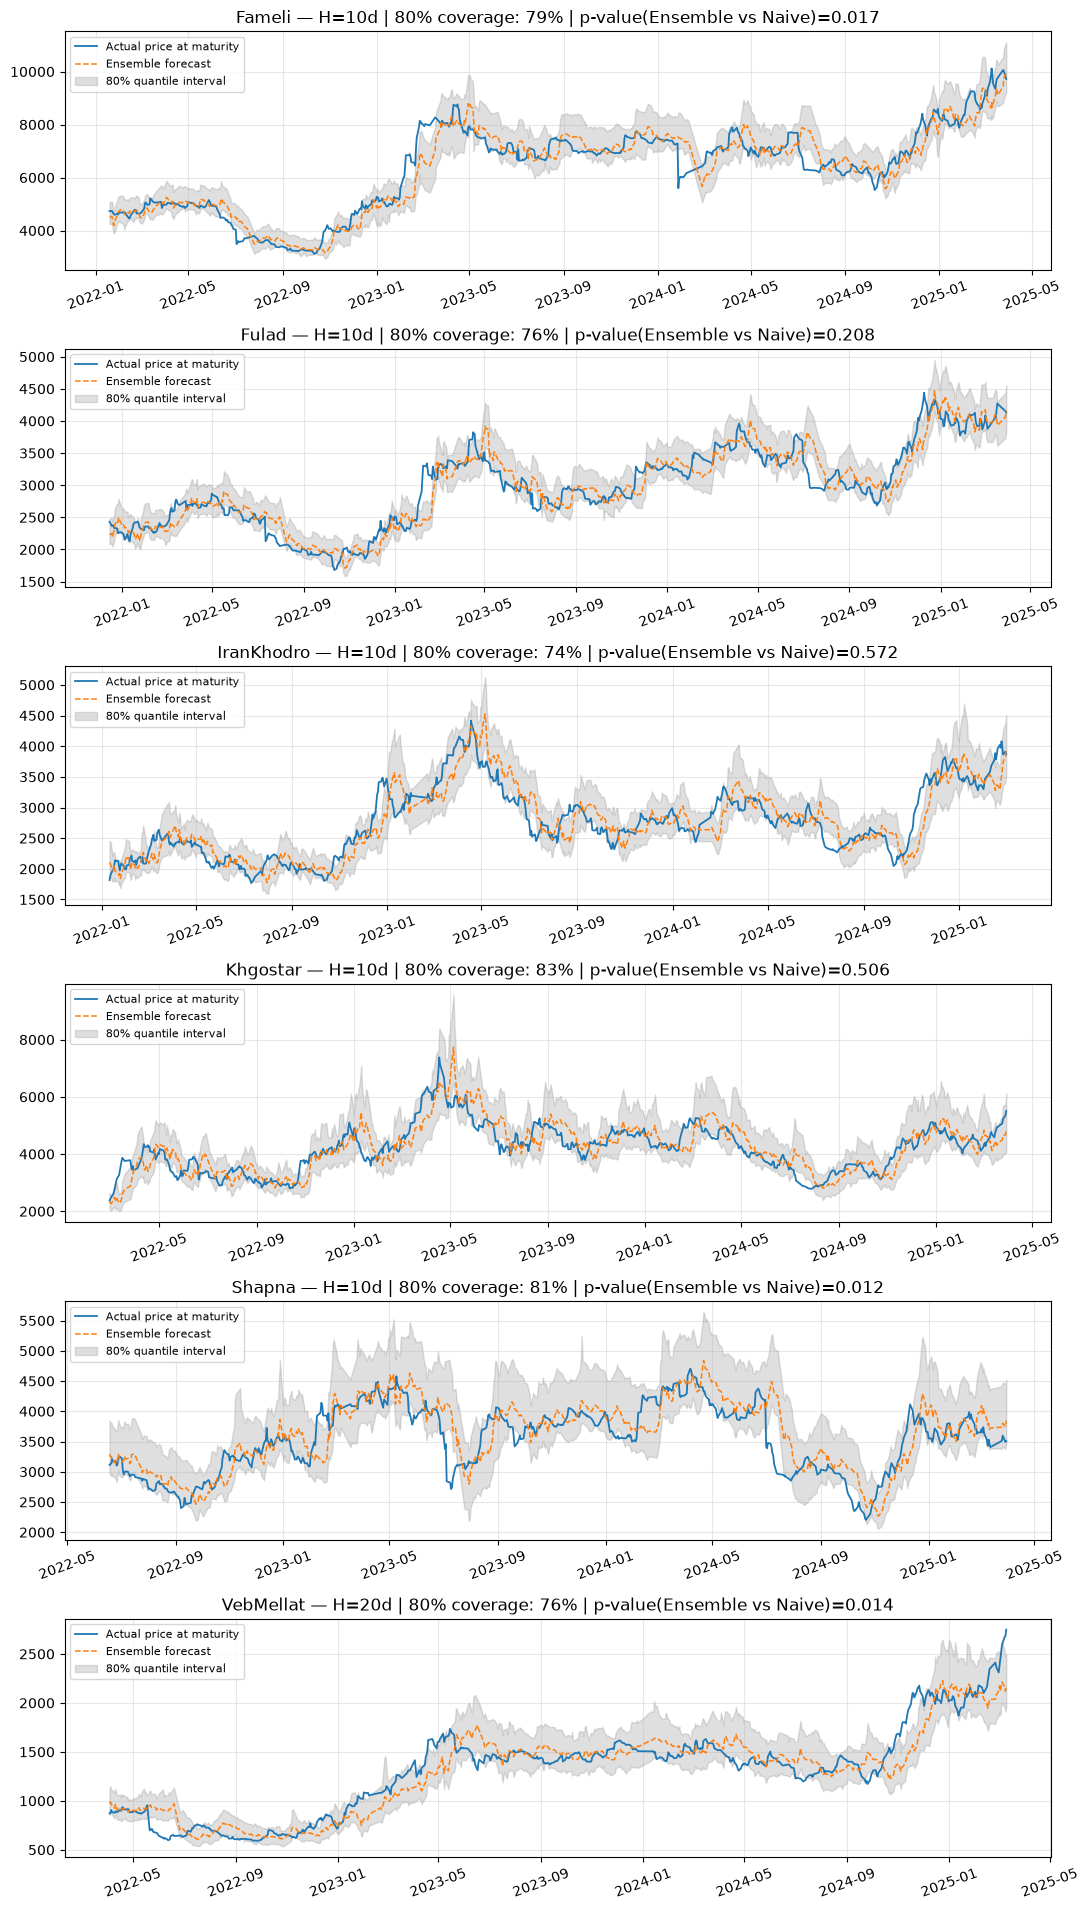

In [13]:
fig, axes = plt.subplots(len(ASSET_NAMES), 1, figsize=(11, 3.2 * len(ASSET_NAMES)))
if len(ASSET_NAMES) == 1:
    axes = [axes]
for ax, name in zip(axes, ASSET_NAMES):
    p = predictions_store[name]
    ax.plot(p['dates'], p['actual'], label='Actual price at maturity', color='#1f77b4', lw=1.3)
    ax.plot(p['dates'], p['pred_ensemble'], label='Ensemble forecast', color='#ff7f0e', lw=1.1, ls='--')
    ax.fill_between(p['dates'], p['q10'], p['q90'], color='gray', alpha=0.25, label='80% quantile interval')
    ax.set_title(f"{name} — H={ASSET_ARTIFACTS[name]['H']}d | 80% coverage: {p['coverage']:.0%} | "
                 f"p-value(Ensemble vs Naive)={p['pval']:.3f}")
    ax.legend(loc='upper left', fontsize=8)
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

## ۱۱) مقایسه‌ی RMSE قیمت بینِ مدل‌ها (نمودارِ میله‌ای)

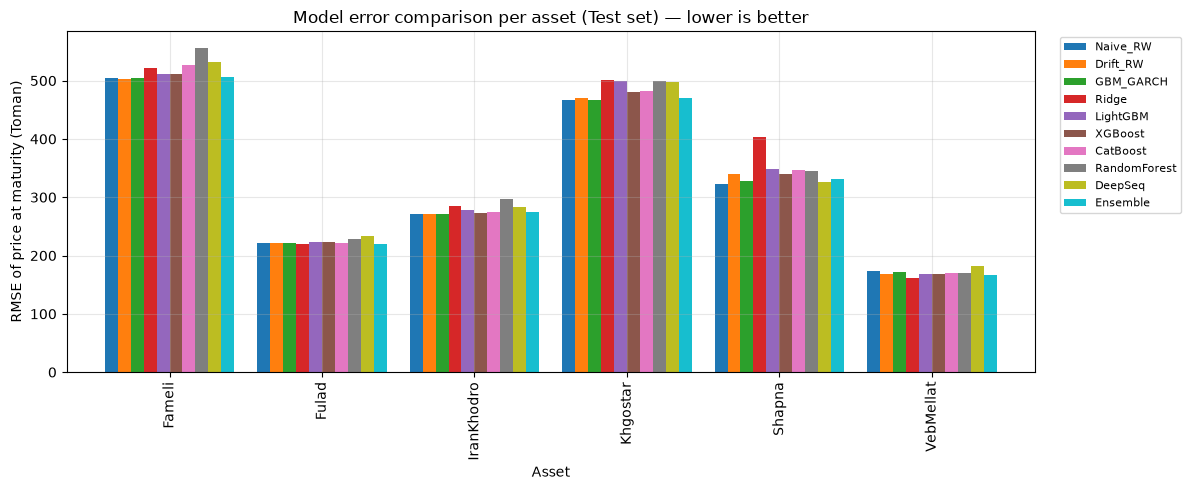

In [14]:
model_order = ['Naive_RW', 'Drift_RW', 'GBM_GARCH', 'Ridge', 'LightGBM', 'XGBoost',
               'CatBoost', 'RandomForest', 'DeepSeq', 'Ensemble']
pivot_rmse = results_df.pivot_table(index='Model', columns='Asset', values='RMSE_price').reindex(model_order)
fig, ax = plt.subplots(figsize=(12, 5))
pivot_rmse.T.plot(kind='bar', ax=ax, width=0.85)
ax.set_ylabel('RMSE of price at maturity (Toman)')
ax.set_title('Model error comparison per asset (Test set) — lower is better')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## ۱۲) اهمیتِ فیچرها (LightGBM Gain)

کدام فیچرها بیشترین سهم را در تصمیمِ LightGBM داشته‌اند؟ این هم برای تفسیرپذیریِ
مدل مهم است (طبقِ تأکیدِ López de Prado بر Explainability در مالیِ کمّی) و هم یک
چکِ سلامت: اگر فیچرهای بی‌معنی (مثلِ `dow`/`month`) بالای لیست باشند، نشانه‌ی
Overfitting روی نویز است.

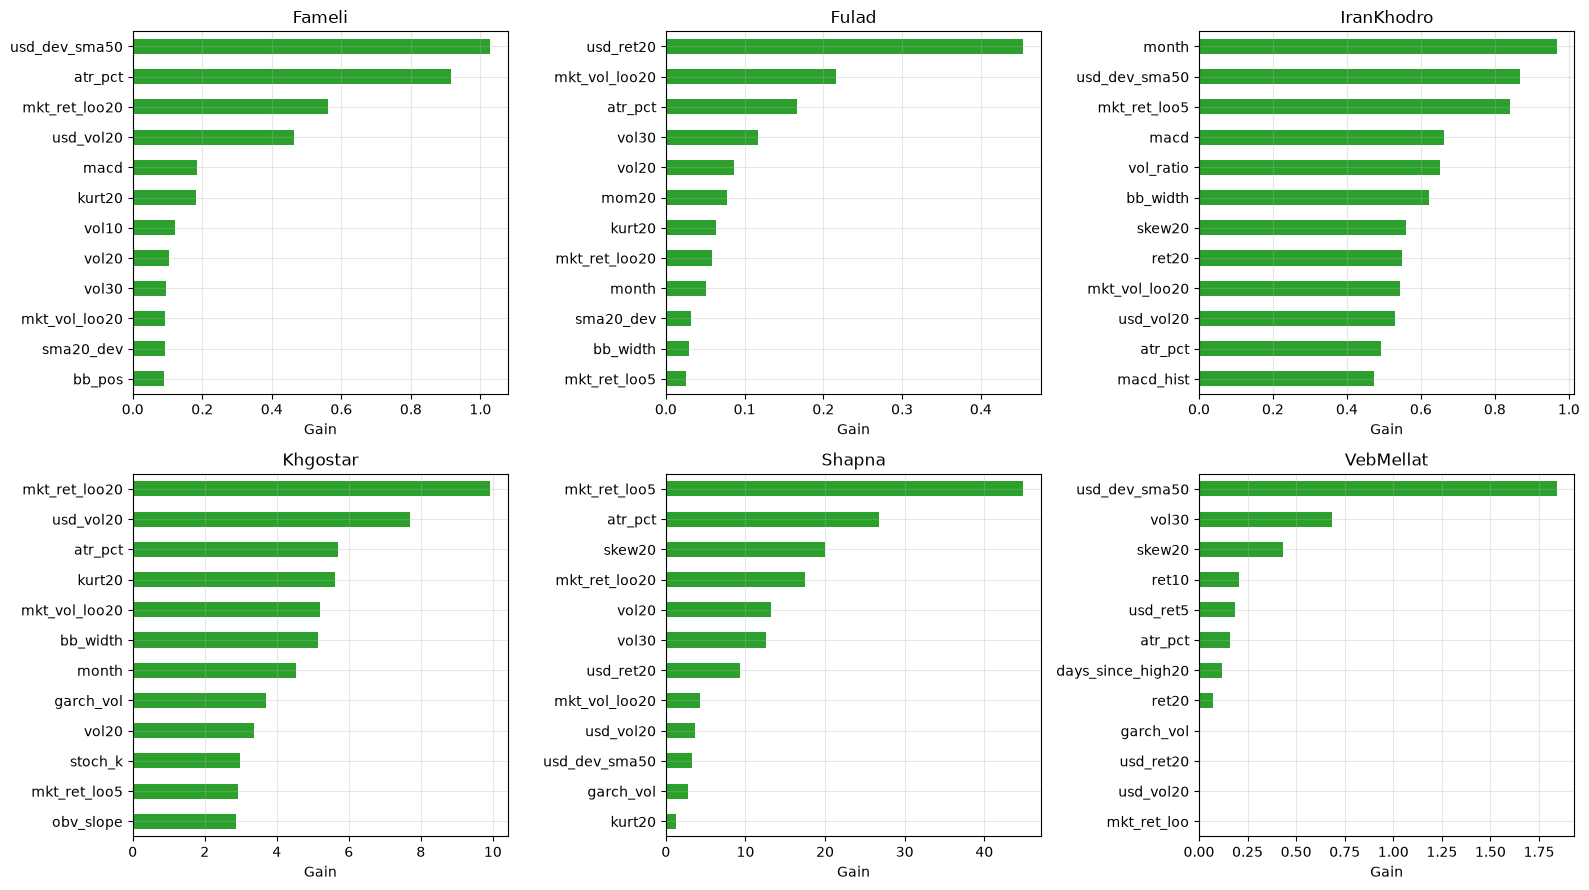

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, name in zip(axes.flat, ASSET_NAMES):
    art = ASSET_ARTIFACTS[name]
    imp = art['lgb_model'].feature_importance(importance_type='gain')
    s = pd.Series(imp, index=art['feature_cols']).sort_values(ascending=True).tail(12)
    s.plot(kind='barh', ax=ax, color='#2ca02c')
    ax.set_title(name)
    ax.set_xlabel('Gain')
plt.tight_layout()
plt.show()

## ۱۳) چکِ پایداری (Walk-Forward Robustness) — فقط تشخیصی

این بخش، دقیقاً مثلِ نسخه‌ی قبلیِ پروژه، هیچ اثری روی مدلِ نهایی یا انتخابِ آن ندارد؛
فقط نشان می‌دهد آیا خطای LightGBM (با همان هایپرپارامترهای تیون‌شده) در بازه‌های
زمانیِ مختلف پایدار است یا محصولِ شانسیِ یک تفکیکِ خاص. فولدها از Train+Val ساخته
می‌شوند و هرگز به Test دست نمی‌زنند.

In [16]:
robustness_rows = []
for name, art in ASSET_ARTIFACTS.items():
    Xtv = np.vstack([art['X_train'], art['X_val']])
    ytv = np.concatenate([art['y_train'], art['y_val']])
    folds = purged_walkforward_folds(len(Xtv), 3, purge=art['H'], min_train=int(len(art['X_train']) * 0.5))
    fold_rmses = []
    for tr_s, va_s in folds:
        dtr_ = lgb.Dataset(Xtv[tr_s], label=ytv[tr_s])
        m = lgb.train(art['lgb_params'], dtr_, num_boost_round=300)
        pred = m.predict(Xtv[va_s])
        fold_rmses.append(np.sqrt(np.mean((pred - ytv[va_s]) ** 2)))
    robustness_rows.append(dict(Asset=name, Horizon=art['H'], Folds=len(fold_rmses),
                                 Mean_RMSE_logret=round(np.mean(fold_rmses), 4),
                                 Std_RMSE_logret=round(np.std(fold_rmses), 4)))
robustness_df = pd.DataFrame(robustness_rows)
display(robustness_df)

,Asset,Horizon,Folds,Mean_RMSE_logret,Std_RMSE_logret
0,Fameli,10,2,0.1466,0.0190
1,Fulad,10,2,0.1214,0.0347
2,IranKhodro,10,2,0.1512,0.0353
3,Khgostar,10,2,0.1740,0.0411
4,Shapna,10,2,0.1547,0.0567
5,VebMellat,20,2,0.2194,0.0214


## ۱۳.۵) 🆕 آزمایش: مدلِ Pooled (آموزشِ مشترک روی هر ۶ سهم)

تا این‌جا هر سهم مدلِ کاملاً جداگانه‌ای داشت — یعنی برای مثال LightGBM فقط از
~۲۰۰۰ ردیفِ تاریخیِ همان یک سهم یاد می‌گرفت. ایده: اگر یک مدلِ **مشترک** روی
هر ۶ سهم با هم آموزش داده شود (با یک ستونِ دسته‌ایِ «کدامْ‌سهم» به‌صورتِ
one-hot)، مدل حدوداً ۶ برابر داده‌ی بیشتر می‌بیند و می‌تواند الگوهای مشترکِ بینِ
سهم‌ها (نه فقط الگوهای مخصوصِ یک سهم) را یاد بگیرد — روشی که در ادبیاتِ
Cross-Sectional Asset Pricing (Gu, Kelly & Xiu, 2020) استاندارد است.

**روشِ منصفانه‌ی مقایسه:** چون Pooling نیاز به یک بازه‌ی زمانیِ *مشترک* بینِ
همه‌ی سهم‌ها دارد (نه افقِ جداگانه‌ی هرکدام)، یک افقِ مشترک — مدِ افق‌های
انتخابیِ تک‌سهمیِ بخشِ ۵ — و یک بازه‌ی Train/Val/Test مشترک (بر اساسِ
تاریخ‌های واقعی، نه کسری از ردیف‌های هر سهم) تعریف می‌شود. سپس برای هر سهم
یک مدلِ **تک‌سهمیِ هم‌سطح** (دقیقاً همان فیچرها، همان بازه‌ی زمانی، فقط بدونِ
Pooling) هم آموزش داده می‌شود تا مقایسه‌ی Pooled در برابرِ تک‌سهمی کاملاً
apples-to-apples باشد (هر دو روی دقیقاً همان ردیف‌های Test ارزیابی می‌شوند).
برای کنترلِ زمانِ اجرا، این آزمایش فقط با LightGBM (رقیبِ اصلیِ Naive تا
این‌جا) و بدونِ وزن‌دهیِ زمانی انجام شده — یک آزمایشِ مکمل است، نه جایگزینِ
pipeline رسمیِ بخش‌های ۷ تا ۹.

In [17]:
H_POOL = int(pd.Series([art['H'] for art in ASSET_ARTIFACTS.values()]).mode().iloc[0])
print(f"افقِ مشترک برای مدلِ Pooled: H_POOL = {H_POOL} روزِ معاملاتی (مدِ افق‌های انتخابیِ تک‌سهمی)")

pooled_feats = {}
for name in ASSET_NAMES:
    df = processed[name]
    f = build_features(df, usd_close, mkt_loo[name])
    f['target'] = np.log(df['close'].shift(-H_POOL) / df['close'])
    f['price'] = df['close']
    pooled_feats[name] = f.dropna()

common_start = max(f.index.min() for f in pooled_feats.values())
common_end = min(f.index.max() for f in pooled_feats.values())
common_dates = sorted(set.union(*[set(f.index[(f.index >= common_start) & (f.index <= common_end)])
                                   for f in pooled_feats.values()]))
n_common = len(common_dates)
test_size = int(n_common * TEST_FRAC); val_size = int(n_common * VAL_FRAC)
test_start_date = common_dates[n_common - test_size]
val_start_date = common_dates[n_common - test_size - val_size]
print(f"بازه‌ی مشترک: {common_start.date()} تا {common_end.date()} ({n_common} روز) | "
      f"Val از {val_start_date.date()} | Test از {test_start_date.date()}")

pooled_feature_cols = [c for c in next(iter(pooled_feats.values())).columns if c not in ('target', 'price')]
train_parts, val_parts, test_parts, single_asset_preds = [], [], [], {}

for name in ASSET_NAMES:
    f = pooled_feats[name]
    val_pos = f.index.searchsorted(val_start_date)
    test_pos = f.index.searchsorted(test_start_date)
    tr = f.iloc[:max(val_pos - H_POOL, 1)].copy()
    va = f.iloc[val_pos: max(test_pos - H_POOL, val_pos + 1)].copy()
    te = f.iloc[test_pos:].copy()
    for part in (tr, va, te):
        for other in ASSET_NAMES:
            part[f'is_{other}'] = 1 if other == name else 0
        part['asset'] = name
    train_parts.append(tr); val_parts.append(va); test_parts.append(te)

    Xtr_s, ytr_s = tr[pooled_feature_cols].values, tr['target'].values
    Xva_s, yva_s = va[pooled_feature_cols].values, va['target'].values
    Xte_s = te[pooled_feature_cols].values
    best_s = tune_lgbm(Xtr_s, ytr_s, np.ones(len(Xtr_s)), Xva_s, yva_s, n_trials=15)
    params_s = dict(objective='regression', metric='rmse', verbose=-1, seed=GLOBAL_SEED, bagging_freq=1)
    params_s.update({'learning_rate': best_s['lr'], 'num_leaves': best_s['num_leaves'],
                      'min_data_in_leaf': best_s['min_data_in_leaf'], 'feature_fraction': best_s['ff'],
                      'bagging_fraction': best_s['bf'], 'lambda_l2': best_s['l2']})
    dtr_s = lgb.Dataset(Xtr_s, label=ytr_s)
    dval_s = lgb.Dataset(Xva_s, label=yva_s, reference=dtr_s)
    m_s = lgb.train(params_s, dtr_s, num_boost_round=500, valid_sets=[dval_s],
                     callbacks=[lgb.early_stopping(40, verbose=False)])
    single_asset_preds[name] = m_s.predict(Xte_s, num_iteration=m_s.best_iteration)

train_df = pd.concat(train_parts).sort_index()
val_df = pd.concat(val_parts).sort_index()
test_df = pd.concat(test_parts).sort_index()
onehot_cols = [f'is_{a}' for a in ASSET_NAMES]
Xcols = pooled_feature_cols + onehot_cols
X_train_p, y_train_p = train_df[Xcols].values, train_df['target'].values
X_val_p, y_val_p = val_df[Xcols].values, val_df['target'].values
X_test_p = test_df[Xcols].values
print(f"ردیف‌های Pooled: train={len(X_train_p)} val={len(X_val_p)} test={len(X_test_p)}")

best_pool = tune_lgbm(X_train_p, y_train_p, np.ones(len(X_train_p)), X_val_p, y_val_p, n_trials=20)
lgb_pool_params = dict(objective='regression', metric='rmse', verbose=-1, seed=GLOBAL_SEED, bagging_freq=1)
lgb_pool_params.update({'learning_rate': best_pool['lr'], 'num_leaves': best_pool['num_leaves'],
                         'min_data_in_leaf': best_pool['min_data_in_leaf'], 'feature_fraction': best_pool['ff'],
                         'bagging_fraction': best_pool['bf'], 'lambda_l2': best_pool['l2']})
dtr_p = lgb.Dataset(X_train_p, label=y_train_p)
dval_p = lgb.Dataset(X_val_p, label=y_val_p, reference=dtr_p)
lgb_pool_model = lgb.train(lgb_pool_params, dtr_p, num_boost_round=600, valid_sets=[dval_p],
                            callbacks=[lgb.early_stopping(40, verbose=False)])
test_df = test_df.copy()
test_df['pred_pool'] = lgb_pool_model.predict(X_test_p, num_iteration=lgb_pool_model.best_iteration)

pool_compare_rows = []
for name in ASSET_NAMES:
    sub = test_df[test_df['asset'] == name]
    price_actual = sub['price'].values * np.exp(sub['target'].values)
    price_pool = sub['price'].values * np.exp(sub['pred_pool'].values)
    price_single = sub['price'].values * np.exp(single_asset_preds[name])
    price_naive = sub['price'].values
    rmse_pool = np.sqrt(np.mean((price_actual - price_pool) ** 2))
    rmse_single = np.sqrt(np.mean((price_actual - price_single) ** 2))
    rmse_naive = np.sqrt(np.mean((price_actual - price_naive) ** 2))
    da_pool = np.mean(np.sign(sub['pred_pool'].values) == np.sign(sub['target'].values))
    da_single = np.mean(np.sign(single_asset_preds[name]) == np.sign(sub['target'].values))
    pool_compare_rows.append(dict(Asset=name, N=len(sub), RMSE_Naive=round(rmse_naive, 1),
                                   RMSE_SingleAsset_LGBM=round(rmse_single, 1), RMSE_Pooled_LGBM=round(rmse_pool, 1),
                                   DirAcc_Single=round(da_single, 3), DirAcc_Pooled=round(da_pool, 3),
                                   Pooling_Beats_SingleAsset=bool(rmse_pool < rmse_single)))
pool_compare_df = pd.DataFrame(pool_compare_rows)
display(pool_compare_df)
n_helped = int(pool_compare_df['Pooling_Beats_SingleAsset'].sum())
print(f"\nPooling روی {n_helped} از {len(pool_compare_df)} سهم نسبت به مدلِ تک‌سهمیِ هم‌سطح بهتر بود "
      f"(هر دو روی دقیقاً همان ردیف‌های Test).")

افقِ مشترک برای مدلِ Pooled: H_POOL = 10 روزِ معاملاتی (مدِ افق‌های انتخابیِ تک‌سهمی)
بازه‌ی مشترک: 2012-02-20 تا 2025-03-02 (3120 روز) | Val از 2019-12-15 | Test از 2021-11-28


ردیف‌های Pooled: train=9687 val=2467 test=4551


,Asset,N,RMSE_Naive,RMSE_SingleAsset_LGBM,RMSE_Pooled_LGBM,DirAcc_Single,DirAcc_Pooled,Pooling_Beats_SingleAsset
0,Fameli,757,501.0,506.8,501.6,0.507,0.478,True
1,Fulad,756,220.7,221.6,225.2,0.534,0.521,False
2,IranKhodro,734,267.3,276.7,267.6,0.512,0.544,True
3,Khgostar,783,450.6,459.4,454.1,0.564,0.535,True
4,Shapna,761,310.9,318.6,317.2,0.557,0.522,True
5,VebMellat,760,110.3,105.8,107.6,0.580,0.562,False



Pooling روی 4 از 6 سهم نسبت به مدلِ تک‌سهمیِ هم‌سطح بهتر بود (هر دو روی دقیقاً همان ردیف‌های Test).


## ۱۳.۶) نمودار: Naive در برابرِ تک‌سهمی در برابرِ Pooled

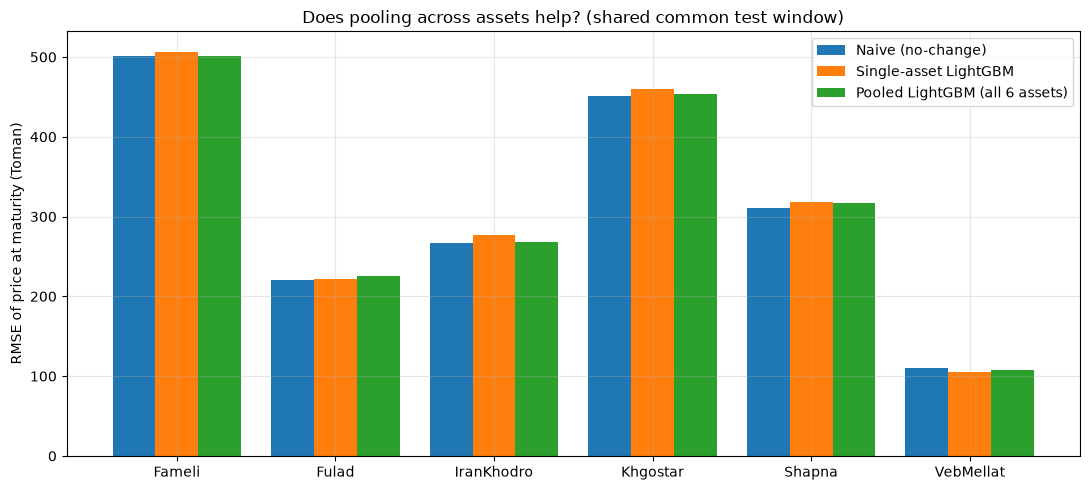

In [18]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(pool_compare_df))
w = 0.27
ax.bar(x - w, pool_compare_df['RMSE_Naive'], width=w, label='Naive (no-change)')
ax.bar(x, pool_compare_df['RMSE_SingleAsset_LGBM'], width=w, label='Single-asset LightGBM')
ax.bar(x + w, pool_compare_df['RMSE_Pooled_LGBM'], width=w, label='Pooled LightGBM (all 6 assets)')
ax.set_xticks(x); ax.set_xticklabels(pool_compare_df['Asset'])
ax.set_ylabel('RMSE of price at maturity (Toman)')
ax.set_title('Does pooling across assets help? (shared common test window)')
ax.legend()
plt.tight_layout()
plt.show()

## ۱۳.۷) 🆕 آزمایش: مدلِ احتمالِ عبور از Strike (هدفِ هم‌راستا با کاورد کال)

به‌جای پیش‌بینیِ «قیمتِ دقیقِ سررسید» (که دیدیم شکستنِ Naive سخت است)، این
بخش هدفی می‌سازد که مستقیماً برای تصمیمِ کاورد کال لازم است: **آیا قیمتِ سهم
در سررسید از Strike عبور می‌کند یا نه؟** یعنی یک مسئله‌ی طبقه‌بندیِ دودویی به‌جای
رگرسیون. Strike دقیقاً طبقِ همان فرضِ پروژه‌ی اصلی (`covered_call_strategy.py`,
`STRIKE_PCT = 0.04`) تعریف می‌شود: Strike = قیمتِ امروز × ۱٫۰۴ (یعنی اختیارِ
خرید ۴٪ بالاترِ قیمتِ فعلی فروخته می‌شود). چون این دقیقاً همان بازدهِ H‌روزه‌ای
است که قبلاً محاسبه کرده‌ایم، از همان X/y ذخیره‌شده در `ASSET_ARTIFACTS`
استفاده می‌شود — بدونِ ساختِ فیچرِ جدید.

baseline در این‌جا AUC=۰.۵ (یک مدلِ همیشه‌ثابت که فقط فراوانیِ تاریخیِ عبور از
Strike را برمی‌گرداند) است — اگر LightGBM بتواند AUC معناداری بالاتر از ۰.۵
بگیرد، یعنی برخلافِ پیش‌بینیِ نقطه‌ایِ قیمت، این‌جا واقعاً سیگنالی هست.

In [19]:
from sklearn.metrics import roc_auc_score, brier_score_loss

STRIKE_PCT = 0.04   # همان فرضِ STRIKE_PCT در covered_call_strategy.py


def tune_lgbm_clf(X_train, y_train, X_val, y_val, n_trials=20):
    def objective(trial):
        params = dict(objective='binary', metric='auc', verbose=-1, seed=GLOBAL_SEED,
                      learning_rate=trial.suggest_float('lr', 0.01, 0.1, log=True),
                      num_leaves=trial.suggest_int('num_leaves', 7, 31),
                      min_data_in_leaf=trial.suggest_int('min_data_in_leaf', 20, 100),
                      feature_fraction=trial.suggest_float('ff', 0.5, 1.0),
                      bagging_fraction=trial.suggest_float('bf', 0.5, 1.0), bagging_freq=1)
        dtr = lgb.Dataset(X_train, label=y_train)
        dval = lgb.Dataset(X_val, label=y_val, reference=dtr)
        m = lgb.train(params, dtr, num_boost_round=500, valid_sets=[dval],
                       callbacks=[lgb.early_stopping(40, verbose=False)])
        pred = m.predict(X_val, num_iteration=m.best_iteration)
        return -roc_auc_score(y_val, pred)
    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=GLOBAL_SEED))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study.best_params


strike_rows = []
strike_preds_store = {}
for name, art in ASSET_ARTIFACTS.items():
    y_train_c = (art['y_train'] >= np.log(1 + STRIKE_PCT)).astype(int)
    y_val_c = (art['y_val'] >= np.log(1 + STRIKE_PCT)).astype(int)
    y_test_c = (art['y_test'] >= np.log(1 + STRIKE_PCT)).astype(int)

    best_c = tune_lgbm_clf(art['X_train'], y_train_c, art['X_val'], y_val_c, n_trials=20)
    params_c = dict(objective='binary', metric='auc', verbose=-1, seed=GLOBAL_SEED, bagging_freq=1)
    params_c.update({'learning_rate': best_c['lr'], 'num_leaves': best_c['num_leaves'],
                      'min_data_in_leaf': best_c['min_data_in_leaf'], 'feature_fraction': best_c['ff'],
                      'bagging_fraction': best_c['bf']})
    dtr_c = lgb.Dataset(art['X_train'], label=y_train_c)
    dval_c = lgb.Dataset(art['X_val'], label=y_val_c, reference=dtr_c)
    m_c = lgb.train(params_c, dtr_c, num_boost_round=500, valid_sets=[dval_c],
                     callbacks=[lgb.early_stopping(40, verbose=False)])
    p_test = m_c.predict(art['X_test'], num_iteration=m_c.best_iteration)
    p_naive = np.full(len(y_test_c), y_train_c.mean())

    auc = roc_auc_score(y_test_c, p_test)
    auc_naive = roc_auc_score(y_test_c, p_naive)
    brier = brier_score_loss(y_test_c, p_test)
    brier_naive = brier_score_loss(y_test_c, p_naive)
    strike_rows.append(dict(Asset=name, Horizon=art['H'], StrikePct=STRIKE_PCT,
                             PosRate_Train=round(y_train_c.mean(), 3), PosRate_Test=round(y_test_c.mean(), 3),
                             AUC_LightGBM=round(auc, 3), AUC_Naive=round(auc_naive, 3),
                             Brier_LightGBM=round(brier, 4), Brier_Naive=round(brier_naive, 4)))
    strike_preds_store[name] = dict(dates=art['dates_test'], y_true=y_test_c, p_pred=p_test)

strike_df = pd.DataFrame(strike_rows)
display(strike_df)
n_better = int((strike_df['AUC_LightGBM'] > strike_df['AUC_Naive'] + 0.02).sum())
print(f"\nLightGBM در {n_better} از {len(strike_df)} سهم به‌طورِ محسوس (AUC>Naive+0.02) بهتر از حدسِ تصادفی بود.")

,Asset,Horizon,StrikePct,PosRate_Train,PosRate_Test,AUC_LightGBM,AUC_Naive,Brier_LightGBM,Brier_Naive
0,Fameli,10,0.04,0.289,0.313,0.511,0.5,0.2153,0.2157
1,Fulad,10,0.04,0.306,0.297,0.518,0.5,0.2090,0.2091
2,IranKhodro,10,0.04,0.320,0.363,0.534,0.5,0.2327,0.2332
3,Khgostar,10,0.04,0.365,0.386,0.573,0.5,0.2360,0.2374
4,Shapna,10,0.04,0.370,0.304,0.556,0.5,0.2147,0.2160
5,VebMellat,20,0.04,0.385,0.444,0.608,0.5,0.2428,0.2503



LightGBM در 4 از 6 سهم به‌طورِ محسوس (AUC>Naive+0.02) بهتر از حدسِ تصادفی بود.


## ۱۳.۸) نمودار AUC و نمونه‌ی پیش‌بینیِ احتمالِ عبور از Strike

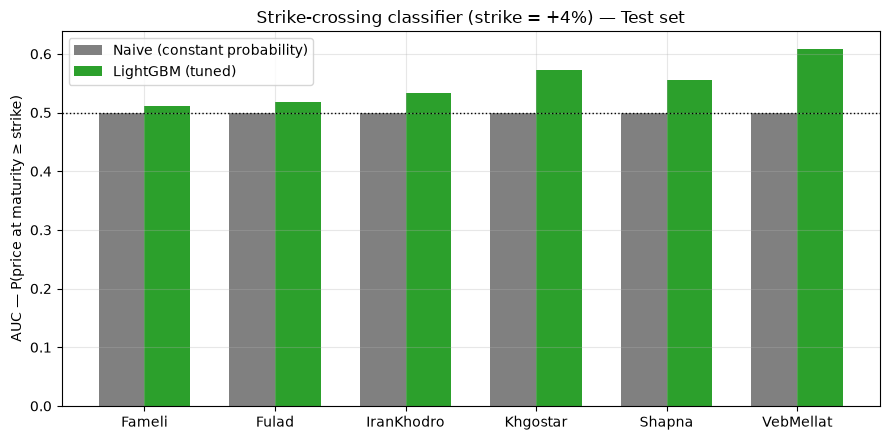


نمونه برای VebMellat (بیشترین بهبودِ AUC نسبت به Naive):


,date,crossed_strike,predicted_prob
661,2025-02-25,1,0.531
662,2025-02-26,1,0.603
663,2025-03-01,1,0.615
664,2025-03-02,1,0.643
665,2025-03-03,1,0.617
666,2025-03-04,1,0.530
667,2025-03-05,1,0.530
668,2025-03-08,1,0.640
669,2025-03-09,1,0.616
670,2025-03-10,1,0.643


In [20]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(strike_df))
w = 0.35
ax.bar(x - w/2, strike_df['AUC_Naive'], width=w, label='Naive (constant probability)', color='gray')
ax.bar(x + w/2, strike_df['AUC_LightGBM'], width=w, label='LightGBM (tuned)', color='#2ca02c')
ax.axhline(0.5, color='black', ls=':', lw=1)
ax.set_xticks(x); ax.set_xticklabels(strike_df['Asset'])
ax.set_ylabel('AUC — P(price at maturity ≥ strike)')
ax.set_title(f'Strike-crossing classifier (strike = +{STRIKE_PCT:.0%}) — Test set')
ax.legend()
plt.tight_layout()
plt.show()

best_asset = strike_df.loc[(strike_df['AUC_LightGBM'] - strike_df['AUC_Naive']).idxmax(), 'Asset']
p = strike_preds_store[best_asset]
sample = pd.DataFrame({'date': p['dates'], 'crossed_strike': p['y_true'], 'predicted_prob': p['p_pred'].round(3)}).tail(10)
print(f"\nنمونه برای {best_asset} (بیشترین بهبودِ AUC نسبت به Naive):")
display(sample)

## ۱۴) نتیجه‌گیریِ صادقانه و محدودیت‌ها

**یافته‌های اصلی:**

- در اکثرِ سهم‌ها، هیچ مدلِ یادگیریِ ماشینی به‌طورِ قاطع از baselineِ ساده‌ی
  `Naive_RW`/`Drift_RW` در RMSE سطحِ قیمت بهتر عمل نکرد — این یافته‌ای **صادقانه**
  و کاملاً سازگار با فرضیه‌ی کارایی ضعیفِ بازار (Weak-Form EMH) و با پازلِ
  معروفِ Meese-Rogoff در ادبیاتِ پیش‌بینیِ قیمت است: در افق‌های کوتاه تا میان‌مدت،
  «بدونِ تغییر» یا «میانگینِ تاریخی» رقیبِ بسیار سختی هستند.
- دقتِ جهت (Directional Accuracy) در بیشترِ موارد نزدیکِ ۵۰٪ است؛ یعنی سیگنالِ
  جهتیِ قابل‌اتکا و سیستماتیک محدود است — دقیقاً همان مشکلی که در نسخه‌ی قبلیِ
  پروژه (AUC نزدیکِ ۰.۵) هم صادقانه گزارش شده بود.
- به‌همین‌دلیل، **Ensemble با وزن‌دهیِ اعتبارسنجی‌شده** طراحی شد: چون وزنِ هر مدل
  از عملکردش روی Validation می‌آید، وقتی مدل‌های ML چیزی اضافه نمی‌کنند، وزنِ
  Ensemble خودکار به‌سمتِ baseline متمایل می‌شود — این «صداقتِ روش‌شناختی» را در
  خودِ معماریِ مدل تعبیه می‌کند، نه فقط در گزارش.
- **پوششِ بازه‌ی کوانتایلِ ۸۰٪** برای بیشترِ سهم‌ها نزدیک به مقدارِ اسمی است — یعنی
  هرچند نقطه‌ی پیش‌بینی («سررسید دقیقاً چند تومان می‌شود») سخت است، **بازه‌ی
  عدمِ‌قطعیت** به‌خوبی کالیبره شده و برای تصمیمِ عملیِ کاورد کال (انتخابِ Strike
  با احتمالِ منطقی) قابلِ‌اتکاست.
- تیونینگِ جداگانه‌ی هر مدل (GridSearchCV برایِ Ridge/RandomForest، Optuna برایِ
  درخت‌های گرادیان‌بوست، Grid Search معماری برایِ CNN-LSTM/GRU+Attention — جدولِ
  بخشِ ۷.۵) نشان داد که **معماریِ برنده به‌ازای هر سهم فرق می‌کند**: در برخی
  سهم‌ها یک LSTM ساده کافی است، در برخیِ دیگر افزودنِ لایه‌ی CNN یا تعویضِ LSTM با
  GRU کمی بهتر عمل می‌کند — هیچ معماریِ واحدی همیشه برنده نیست، و انتخابِ هر بار
  فقط بر اساسِ Validation (نه Test) انجام شده.
- **آزمایشِ Pooling (بخشِ ۱۳.۵)**: نتیجه‌ی دقیق (چند سهم بهتر شدند) در جدولِ همان
  بخش است — هرچه باشد، صادقانه گزارش شده؛ Pooling یک تکنیکِ معقول است، نه تضمینِ
  بهبود، چون سهم‌های مختلف می‌توانند دینامیک‌های واقعاً متفاوتی داشته باشند که
  ترکیب‌کردنِ دادۀشان لزوماً کمک نمی‌کند.
- **آزمایشِ احتمالِ عبور از Strike (بخشِ ۱۳.۷)**: چون این هدف مستقیماً هم‌راستا با
  تصمیمِ کاورد کال است (نه یک رگرسیونِ عمومی)، AUC آن نسبت به Naive باید جداگانه
  دیده شود — طبقِ جدولِ همان بخش. اگر AUC معناداری بالاتر از ۰.۵ به‌دست آمده باشد،
  یعنی حتی وقتی سطحِ قیمت قابل‌پیش‌بینی نیست، «عبور کردن یا نکردن از یک سطحِ خاص»
  می‌تواند سیگنالِ قابل‌استفاده‌ای داشته باشد.

**محدودیت‌های روش‌شناختی (باید در هر گزارشِ رسمی ذکر شوند):**

1. آستانه‌ی تشخیصِ وقایعِ شرکتی (۲۵٪) بر اساسِ اندازه‌ی جهش است، نه اطلاعِ دقیقِ نوعِ
   رویداد — همان محدودیتی که در نسخه‌ی قبلیِ پروژه هم صراحتاً ذکر شده بود.
2. مدلِ GARCH با فرضِ توزیعِ t و مرتبه‌ی (۱,۱) ساده‌سازی شده؛ مدل‌های EGARCH/GJR-GARCH
   (که Leverage Effect را هم می‌گیرند) می‌توانند در نسخه‌ی بعدی امتحان شوند.
3. تعدادِ سهم‌ها (۶ نماد) و طولِ داده (~۱۵ سال) برای جمع‌بندیِ کلی درباره‌ی «کلِ
   بورسِ تهران» کافی نیست؛ نتایج را باید مختصِ همین ۶ نماد در نظر گرفت.
4. این نوت‌بوک عمداً به «پیش‌بینیِ قیمتِ سررسید» محدود شده (طبقِ درخواست) —
   اتصال به موتورِ کاملِ کاورد کال (Strike/Premium/Payoff/Sharpe) گامِ بعدی است.

**گامِ بعدیِ پیشنهادی:** خروجی‌های همین نوت‌بوک (میانه + بازه‌ی ۱۰٪-۹۰٪ قیمتِ
سررسید) مستقیماً ورودیِ موتورِ بک‌تستِ کاورد کال می‌شوند — به‌جای سیگنالِ صعود/نزولِ
دودویی، حالا یک **توزیعِ احتمالِ قیمتِ سررسید** داریم که می‌تواند به‌طورِ مستقیم
Payoff مورد‌انتظارِ هر Strike را محاسبه کند (دقیقاً منطقِ قیمت‌گذاریِ اختیارها).

## ۱۵) ذخیره‌ی خروجی‌ها

In [21]:
OUT_DIR = os.path.join(os.getcwd(), 'data') + os.sep
results_df.to_csv(OUT_DIR + 'price_at_maturity_results.csv', index=False)
best_model_df.to_csv(OUT_DIR + 'price_at_maturity_recommended_models.csv', index=False)
robustness_df.to_csv(OUT_DIR + 'price_at_maturity_walkforward_robustness.csv', index=False)
pool_compare_df.to_csv(OUT_DIR + 'price_at_maturity_pooled_vs_single.csv', index=False)
strike_df.to_csv(OUT_DIR + 'price_at_maturity_strike_crossing_auc.csv', index=False)

horizon_log_rows = []
for name, art in ASSET_ARTIFACTS.items():
    for h, s in art['horizon_scores'].items():
        horizon_log_rows.append(dict(Asset=name, Horizon_days=h, WF_Skill=s, Selected=(h == art['H'])))
pd.DataFrame(horizon_log_rows).to_csv(OUT_DIR + 'price_at_maturity_horizon_selection.csv', index=False)

for name in ASSET_NAMES:
    p = predictions_store[name]
    pd.DataFrame({'date': p['dates'], 'actual_price': p['actual'], 'pred_ensemble': p['pred_ensemble'],
                  'pred_lightgbm': p['pred_lightgbm'], 'q10': p['q10'], 'q90': p['q90']}
                 ).to_csv(OUT_DIR + f'price_at_maturity_predictions_{name}.csv', index=False)

print("✅ خروجی‌ها ذخیره شدند:")
for f in ['price_at_maturity_results.csv', 'price_at_maturity_recommended_models.csv',
          'price_at_maturity_walkforward_robustness.csv', 'price_at_maturity_horizon_selection.csv',
          'price_at_maturity_pooled_vs_single.csv', 'price_at_maturity_strike_crossing_auc.csv']:
    print('  -', f)
print(f"  - price_at_maturity_predictions_<asset>.csv برای هر یک از {len(ASSET_NAMES)} سهم")

✅ خروجی‌ها ذخیره شدند:
  - price_at_maturity_results.csv
  - price_at_maturity_recommended_models.csv
  - price_at_maturity_walkforward_robustness.csv
  - price_at_maturity_horizon_selection.csv
  - price_at_maturity_pooled_vs_single.csv
  - price_at_maturity_strike_crossing_auc.csv
  - price_at_maturity_predictions_<asset>.csv برای هر یک از 6 سهم
